# REE Separation from Bastnasite Concentrate

This notebook builds a single extract-scrub-strip circuit on a **bastnasite**
concentrate leach liquor and works it through to a cost structure, using
`difflow_ree`.

## What this notebook is, and is not

It is a worked example of the *machinery*: how to put a real ore composition on
a defensible basis, how to read a distribution-coefficient correlation and stay
inside the window it was fitted over, how to close a mass balance across every
outlet of a circuit with an internal recycle, and how a cost estimate responds
to the design.

It is **not** a technoeconomic evaluation of a rare earth project, and no number
printed below should be quoted as one. The reason is about data, and section 0
gets it from the database rather than asking you to take it on trust. Since
`#270` the part that used to be weakest is no longer weak: PC88A's pH
coefficients are now a refit of Tanaka et al. (2021), so the distribution
coefficients are `MEASURED`. Everything the *economics* rests on is still soft —
half the prices carry a USGS citation and half are `ESTIMATED`, the payability
is an outright assumption, and every OPEX unit rate is a placeholder.

## What this notebook is careful about

Three things govern every number below, and each is easy to get backwards.

1. **One section makes one cut.** An extract-scrub-strip circuit chooses a point
   on the extractant's affinity ladder and sends everything above it one way and
   everything below it the other. It cannot simultaneously reject elements
   lighter *and* heavier than the target. Whatever sits above the cut in the feed
   is a hard ceiling on product purity, and no pH, stage count or flow ratio
   moves it.
2. **The correlation is valid over `(0.1, 2.5)`, and `b = 3` exactly.** The slope
   is the stoichiometric coefficient of the ion exchange, not a fitted number,
   and it is shared by every element. That has a consequence used throughout:
   with one shared slope, every separation factor is *independent of pH*.
   Selectivity lives entirely in the intercepts.
3. **The plant basis is one number.** The tonnage, the molar flows and the
   aqueous volumetric flow are all derived from a single declared capacity and a
   single declared feed molarity, and the round trip is asserted, so the label
   and the simulation cannot drift apart.

## Process

1. **Feed** — Mountain Pass bastnasite REO distribution, put through the
   oxidative roast that precedes solvent extraction, on a rare-earth-oxide basis
2. **Equilibrium** — PC88A distribution coefficients, and the cut-point ladder
   they imply
3. **Extract-scrub-strip** — one PC88A circuit: Nd and the heavies to the strip
   liquor, La and Ce to the raffinate
4. **Streams** — the scrub recycle closed, and the balance struck on every
   external outlet
5. **Cost structure** — contained-oxide value at an explicit payability, against
   an anchored CAPEX and a factored OPEX


In [1]:
import warnings

import jax
import jax.numpy as jnp
import numpy as np

jax.config.update("jax_enable_x64", True)

from difflow.streams import make_stream, get_flows

from difflow_ree import (
    # Database
    get_element, list_ree_elements, get_extractant,
    # Equilibrium
    REEDistribution,
    # Flowsheets
    ExtractScrubStripCircuit, ExtractScrubStripParams,
    # Economics
    REEPricing, estimate_capex, capex_basis, estimate_opex, calculate_profit,
    ree_oxide_mass_flow,
)
from difflow_ree.database import get_separation_factor, get_sf_database
from difflow_ree.provenance import audit, coverage, explain

HOURS_PER_YEAR = 8000.0
T_OP = 298.15

print("REE elements in database:", list_ree_elements())

REE elements in database: ['La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Y', 'Ho', 'Er', 'Tm', 'Yb', 'Lu']


## 0. Provenance: what the numbers below are worth

`difflow_ree` tags every leaf value in its data files with a provenance class,
resolvable from Python. Before running anything, ask the database what class of
number this notebook is about to depend on.

Four classes appear below, and the distinction between the first two and the
last two is the whole point of this section:

- **`MEASURED`** — read off a published experiment. PC88A's `ph_coefficients`
  are now this: a refit of the log *K*ex series in Tanaka et al. (2021), with the
  slope **pinned at `b = 3`** because the exchange
  `RE³⁺ + 3(HA)₂ ⇌ RE(HA₂)₃ + 3H⁺` releases three protons. They used to be
  `HAND_TUNED`, and everything this notebook says about recovery and purity
  changed when they stopped being.
- **`DERIVED`** — computed from other tagged values in the same database, so it
  cannot drift out of step with them. Three of the intercepts here are
  interpolated between measured neighbours, and, since `#265`, so is every
  separation factor.
- **`REFERENCE`** — a published figure with a citation. Six of the nine oxide
  prices used below are USGS *Mineral Commodity Summaries* values.
- **`ESTIMATED`** — an indicative order of magnitude with no identified source.
  The other three prices, and every cost factor in
  `difflow_ree/economics/costs.py`.

So the *separation* in this notebook now rests on a measurement, and the
*economics* does not. That asymmetry is the honest summary, and it is the
opposite of what this notebook used to say.

One caveat the census below also surfaces: PC88A's **temperature** coefficients
are still `HAND_TUNED`. This notebook runs at 298.15 K, the reference
temperature, where that term is identically zero — so nothing here depends on
them. A study at any other temperature would.


In [2]:
print("Provenance census of the extractant database")
print("=" * 68)
for cls, n in sorted(coverage("extractants").items(), key=lambda kv: -kv[1]):
    print(f"  {cls:<12} {n:>4} values")

print("\nWhat this notebook's distribution coefficients actually are")
print("=" * 68)
for path in ("extractants.PC88A.ph_coefficients.Nd.a",
             "extractants.PC88A.ph_coefficients.Nd.b",
             "extractants.PC88A.ph_coefficients.Pr.a"):
    p = explain("extractants", path)
    print(f"  {path.split('ph_coefficients.')[1]:>5} = {p.value:>9}   [{p.cls}]")
print(f"\n  cite: {explain('extractants', 'extractants.PC88A.ph_coefficients.Nd.a').citation}")

# What is LEFT hand-tuned in the PC88A record, so the caveat is specific rather
# than a blanket disclaimer over a record that no longer deserves one.
hand_tuned = audit(cls="HAND_TUNED")
pc88a_ht = [q for q in hand_tuned if ".PC88A." in q.path]
print(f"\n  {len(hand_tuned)} HAND_TUNED values in the database, "
      f"{len(pc88a_ht)} of them in the PC88A record.")
print("  Every one of those is outside the pH correlation:")
for q in pc88a_ht[:3]:
    print(f"    - {q.path.split('PC88A.')[1]} = {q.value}")
print(f"    - ... and {len(pc88a_ht) - 3} more, all in "
      f"temperature_coefficients / valid_temp_range / concentration_exponent")
assert not any("ph_coefficients" in q.path for q in pc88a_ht), \
    "a pH coefficient is still hand-tuned -- the text above is out of date"

print("\nAnd what the prices are -- mixed, so ask each one")
print("=" * 68)
for elem in ("La", "Ce", "Pr", "Nd", "Sm", "Eu", "Gd", "Dy", "Y"):
    q = explain("elements", f"elements.{elem}.price_usd_kg")
    tag = q.citation.split("(")[0].strip() if q.cls == "REFERENCE" else "no source"
    print(f"  {elem:>3} ${q.value:>8,.2f}/kg oxide   [{q.cls:<9}] {tag}")
print("\n  -> The two prices this plant actually lives on, Pr and Nd, are")
print("     REFERENCE. Sm, Dy and Y are not, and neither is any cost factor")
print("     in difflow_ree/economics/costs.py.")


Provenance census of the extractant database
  HAND_TUNED    123 values
  CONVENTION    117 values
  MEASURED       94 values
  REFERENCE      57 values
  ESTIMATED       9 values
  DERIVED         9 values

What this notebook's distribution coefficients actually are
   Nd.a =   -3.0776   [MEASURED]
   Nd.b =       3.0   [MEASURED]
   Pr.a =   -3.4086   [DERIVED]

  cite: Tanaka, M.; Oki, T.; Koyama, K.; Narita, H. (2021). "Revaluating solvent extraction equilibria of trivalent rare earths with EHEHPA (PC-88A)". Hydrometallurgy 201, 105588.

  123 HAND_TUNED values in the database, 13 of them in the PC88A record.
  Every one of those is outside the pH correlation:
    - temperature_coefficients.La = -1400
    - temperature_coefficients.Ce = -1500
    - temperature_coefficients.Pr = -1600
    - ... and 10 more, all in temperature_coefficients / valid_temp_range / concentration_exponent

And what the prices are -- mixed, so ask each one
   La $    1.00/kg oxide   [REFERENCE] U.S. Geologi

## 1. Bastnasite feed, on a rare-earth-oxide basis

Bastnasite is `(REE)CO₃F`. The Mountain Pass (California) deposit is the
canonical light-REE bastnasite: roughly half the contained rare earth is cerium
and a third is lanthanum, which is exactly why the economics below come out the
way they do — the bulk of the feed is the part of the market that is in
surplus.

**The liquor a plant feeds to solvent extraction is not the ore.** The Molycorp
chloride route runs the flotation concentrate through an oxidative roast at
600–800 °C before it ever sees an extractant, and that roast converts *about half
the Ce(III) present to Ce(IV)*. Ce(IV) does not dissolve in the subsequent HCl
leach; it stays in the residue with the fluorides and is sold on as a low-grade
cerium concentrate. So the leach liquor is already cerium-depleted before
extraction begins, and — because cerium is close to half the rare earth
inventory in this ore — **that furnace does the single largest separation in the
whole flowsheet**, for the price of air.

That is not a detail this notebook can skip. Section 3 shows why: on PC88A the
Ce/Pr gap is the tightest cut anywhere in this feed, so half the Ce removed
upstream is worth more than anything the circuit can be tuned to do. The
composition below is therefore the *roasted-and-leached liquor*, and the
as-mined distribution is kept beside it so the step is visible.

Two things about the oxide basis follow, and both are easy to get wrong.

**Prices are quoted per kg of oxide, not per kg of metal.** Converting between
them is not one factor, because the oxide stoichiometry differs by element:
`La₂O₃` and `Nd₂O₃` carry two metal atoms per formula, `CeO₂` carries one, and
`Pr₆O₁₁` carries six. Multiplying a metal mass by an oxide price understates
the value of a stream by 13 % (Dy) to 21 % (Y), and by a different amount for
each element — so it distorts the *ranking* of which element is carrying the
revenue, not just the level. `difflow_ree.ree_oxide_mass_flow` reads the metal
count off the formula and is used for every mass reported below.

**"t/year REO" has to mean REO.** A plant basis stated in oxide tonnes and a set
of molar flows written down by hand will not agree unless something forces them
to: the same distribution priced on a metal basis is a factor of about 1.2
smaller, so the label and the simulation can disagree while both look
reasonable. Here the molar flows are *derived* from the target REO tonnage, the
aqueous carrier is derived from a declared feed molarity, and the round trip
through `ree_oxide_mass_flow` is asserted.


In [3]:
# Mountain Pass bastnasite AS MINED: distribution of the contained rare earth,
# as wt% of total REO. Indicative of the published ore description; the
# element *ratios* are the point, not the third significant figure.
REO_AS_MINED = {
    "La": 33.8,
    "Ce": 49.6,   # half the ore, and the cheapest REE on the market
    "Pr": 4.1,
    "Nd": 11.2,   # the magnet element; the reason the plant exists
    "Sm": 0.9,
    "Eu": 0.1,
    "Gd": 0.2,
    "Dy": 0.03,   # bastnasite is heavy-poor; Dy is a trace here
    "Y": 0.1,
}

# The oxidative roast converts about half the Ce(III) to Ce(IV), which does not
# dissolve in the HCl leach and reports to the residue as a cerium concentrate.
# Everything else follows the liquor. This is the largest single separation in
# the flowsheet and it happens in a furnace, not a mixer-settler.
CE_TO_TETRAVALENT = 0.50

REO_LIQUOR = {e: (p * (1.0 - CE_TO_TETRAVALENT) if e == "Ce" else p)
              for e, p in REO_AS_MINED.items()}

REO_TONNES_PER_YEAR = 5000.0   # plant basis, tonnes REO/year IN THE LIQUOR
FEED_MOLARITY = 0.30           # mol total RE per litre of aqueous feed

# kg of oxide per mol of rare earth, per element. ree_oxide_mass_flow reads the
# metal-atom count off the oxide formula (CeO2 -> 1, Pr6O11 -> 6, Tb4O7 -> 4,
# everything else 2), so this is the only conversion needed anywhere below.
KG_REO_PER_MOL = {e: float(ree_oxide_mass_flow({e: 1.0})) for e in REO_LIQUOR}

_total_pct = sum(REO_LIQUOR.values())
reo_kg_s = REO_TONNES_PER_YEAR * 1000.0 / (HOURS_PER_YEAR * 3600.0)

bastnasite_composition = {
    e: reo_kg_s * pct / _total_pct / KG_REO_PER_MOL[e]
    for e, pct in REO_LIQUOR.items()
}
all_elements = tuple(bastnasite_composition)

# The basis must close: molar flows -> contained REO -> the tonnage we asked for
reo_check = float(ree_oxide_mass_flow(bastnasite_composition))
assert abs(reo_check - reo_kg_s) / reo_kg_s < 1e-10, "REO basis does not close"

# One capacity, one molarity, one aqueous flow. Nothing below is free to
# disagree with these.
total_re_mol_s = sum(bastnasite_composition.values())
aqueous_L_s = total_re_mol_s / FEED_MOLARITY
FEED_H2O_MOL_S = aqueous_L_s * 1000.0 / 18.015

print(f"Bastnasite leach liquor: {REO_TONNES_PER_YEAR:,.0f} t REO/year "
      f"at {HOURS_PER_YEAR:,.0f} h/year")
print(f"  {total_re_mol_s:.4f} mol RE/s in {aqueous_L_s:.2f} L/s of aqueous "
      f"at {FEED_MOLARITY:.2f} M ({FEED_H2O_MOL_S:.1f} mol H2O/s)")
print("=" * 80)
print(f"{'El':>4} {'as mined':>9} {'liquor':>8} {'mol/s':>10} {'t REO/yr':>10} "
      f"{'oxide':>7} {'kg/mol':>8} {'$/kg ox':>9}")
print("-" * 80)
for elem, flow in bastnasite_composition.items():
    props = get_element(elem)
    t_yr = flow * KG_REO_PER_MOL[elem] * 3600.0 * HOURS_PER_YEAR / 1000.0
    print(f"{elem:>4} {REO_AS_MINED[elem]:>8.2f}% "
          f"{REO_LIQUOR[elem] / _total_pct * 100:>7.2f}% {flow:>10.5f} "
          f"{t_yr:>10.2f} {props.oxide_formula:>7} "
          f"{KG_REO_PER_MOL[elem]:>8.4f} {props.price_usd_kg:>9,.2f}")
print("-" * 80)
print(f"{'TOT':>4} {sum(REO_AS_MINED.values()):>8.2f}% {100.0:>7.2f}% "
      f"{total_re_mol_s:>10.5f} "
      f"{reo_check * 3600 * HOURS_PER_YEAR / 1000:>10.2f}")

_ce_mined = REO_AS_MINED["Ce"] / sum(REO_AS_MINED.values()) * 100
_ce_liq = REO_LIQUOR["Ce"] / _total_pct * 100
_lace = (REO_LIQUOR["La"] + REO_LIQUOR["Ce"]) / _total_pct * 100
print(f"\nThe roast takes Ce from {_ce_mined:.1f}% of the ore to "
      f"{_ce_liq:.1f}% of the liquor.")
print(f"La + Ce is still {_lace:.1f}% of what reaches solvent extraction -- and "
      f"they are the two\ncheapest oxides in the table. That, not the "
      f"separation, is what sets the economics.")


Bastnasite leach liquor: 5,000 t REO/year at 8,000 h/year
  1.0387 mol RE/s in 3.46 L/s of aqueous at 0.30 M (192.2 mol H2O/s)
  El  as mined   liquor      mol/s   t REO/yr   oxide   kg/mol   $/kg ox
--------------------------------------------------------------------------------
  La    33.80%   44.93%    0.47882    2246.44   La2O3   0.1629      1.00
  Ce    49.60%   32.97%    0.33251    1648.28    CeO2   0.1721      1.71
  Pr     4.10%    5.45%    0.05558     272.50  Pr6O11   0.1702     69.00
  Nd    11.20%   14.89%    0.15363     744.38   Nd2O3   0.1682     69.00
  Sm     0.90%    1.20%    0.01191      59.82   Sm2O3   0.1744     15.00
  Eu     0.10%    0.13%    0.00131       6.65   Eu2O3   0.1760     27.00
  Gd     0.20%    0.27%    0.00255      13.29   Gd2O3   0.1812     30.00
  Dy     0.03%    0.04%    0.00037       1.99   Dy2O3   0.1865    450.00
   Y     0.10%    0.13%    0.00204       6.65    Y2O3   0.1129     35.00
--------------------------------------------------------------

## 2. PC88A distribution coefficients, and where they are valid

For a cation-exchange extractant like PC88A (EHEHPA), `difflow_ree` models the
distribution coefficient as

$$\log_{10} D = a + b\,\mathrm{pH} + c\,\mathrm{pH}^2
  + d\left(\tfrac{1}{T} - \tfrac{1}{T_\mathrm{ref}}\right)
  + n \log_{10}\frac{[\mathrm{HA}]}{[\mathrm{HA}]_\mathrm{ref}}$$

Three things about that expression govern everything below.

**`b = 3`, and it is not fitted.** The extraction is the ion exchange

$$\mathrm{RE}^{3+} + 3\,(\mathrm{HA})_2 \rightleftharpoons
  \mathrm{RE}(\mathrm{HA}_2)_3 + 3\,\mathrm{H}^+$$

so mass action gives $\log_{10} D = \log_{10} K_\mathrm{ex}
+ 3\log_{10}[(\mathrm{HA})_2] + 3\,\mathrm{pH}$: the slope is the proton
stoichiometry. The `#270` refit pinned it there rather than letting three free
parameters chase seven points, and `c` went to zero with it. Every element
shares the same $b$.

**With one shared slope, separation factors do not depend on pH.** If
$\log_{10}D_i = a_i + 3\,\mathrm{pH}$ for every $i$, then

$$\log_{10}\beta_{ij} = \log_{10}\frac{D_i}{D_j} = a_i - a_j$$

exactly — no pH, no temperature, no concentration. Selectivity lives entirely in
the intercepts. What pH *does* choose is **where on the intercept ladder to cut
the feed**, which is a completely different question and the one section 3 asks.
Anything that offers to "optimise the pH for selectivity" on a shared-slope
system is optimising round-off.

**It is a fit over a stated window, and the window is `(0.1, 2.5)`.** Tanaka's
measurements do not go higher, so above pH 2.5 the correlation is being
extrapolated — and at three decades per pH unit, one unit of extrapolation is a
factor of a thousand in $D$. `REEDistribution` reports an out-of-range pH as a
warning rather than answering silently. This notebook previously ran at pH 3.2
against a declared window of `[0.1, 5.5]`; both the window and the operating
point changed with the refit, and the last cell in the notebook runs the old
operating point deliberately to show what it now does.


In [4]:
dist = REEDistribution(extractant="PC88A", elements=all_elements)
ext = get_extractant("PC88A")
ph_lo, ph_hi = ext.valid_ph_range

print(f"PC88A ({ext.extractant_type}), valid_ph_range = "
      f"({ph_lo:g}, {ph_hi:g}), reference [HA] = "
      f"{ext.reference_concentration:g} M")
print("D > 1: extracts to organic.  D < 1: stays in the aqueous raffinate.")
print("=" * 80)
show = ("La", "Ce", "Pr", "Nd", "Sm", "Gd", "Dy")
print(f"{'pH':>5} " + " ".join(f"{e:>9}" for e in show) + "   validity")
print("-" * 80)
# on_out_of_range="ignore" here ONLY because the point of this table is to
# display the extrapolated region; the circuit below runs with the default
# "warn" and stays inside the window.
quiet = REEDistribution(extractant="PC88A", elements=all_elements,
                        on_out_of_range="ignore")
for pH in [0.2, 0.5, 1.0, 1.05, 1.5, 2.0, 2.5, 3.0, 3.2]:
    D = quiet.get_D_all(pH, T_OP)
    flag = "fitted" if ph_lo <= pH <= ph_hi else "EXTRAPOLATED"
    print(f"{pH:>5.2f} " + " ".join(f"{float(D[e]):>9.3g}" for e in show)
          + f"   {flag}")

print("\nOutside the window the correlation says so, rather than answering\n"
      "silently:")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    REEDistribution(extractant="PC88A", elements=("Nd",)).get_D("Nd", pH=3.2)
for w in caught:
    print("  " + str(w.message).split(". ")[0] + ".")

print("\nThe coefficients themselves. b is not nearly the same for every")
print("element -- it is exactly the same, and equal to the proton count:")
print(f"  {'element':>8} {'a':>9} {'b':>6} {'c':>6}   provenance of a")
for e in show:
    c = ext.ph_coefficients[e]
    prov = explain("extractants", f"extractants.PC88A.ph_coefficients.{e}.a")
    print(f"  {e:>8} {c.a:>9.4f} {c.b:>6.1f} {c.c:>6.1f}   {prov.cls}")
_bs = {ext.ph_coefficients[e].b for e in all_elements}
assert _bs == {3.0}, f"b is no longer shared and equal to 3: {_bs}"
assert {ext.ph_coefficients[e].c for e in all_elements} == {0.0}

print(f"""
So all of the selectivity is in the spread of a, which runs from
{ext.ph_coefficients['La'].a:.4f} for La to {ext.ph_coefficients['Y'].a:.4f} for Y -- {ext.ph_coefficients['Y'].a - ext.ph_coefficients['La'].a:.2f} decades across the series, or
{(ext.ph_coefficients['Y'].a - ext.ph_coefficients['La'].a) / 3:.2f} pH units of ladder. Every element in this feed has to be sorted
inside that span.""")


PC88A (acidic_phosphonic), valid_ph_range = (0.1, 2.5), reference [HA] = 0.5 M
D > 1: extracts to organic.  D < 1: stays in the aqueous raffinate.
   pH        La        Ce        Pr        Nd        Sm        Gd        Dy   validity
--------------------------------------------------------------------------------


 0.20  0.000332  0.000727   0.00155   0.00333    0.0172     0.126      1.62   fitted
 0.50   0.00263   0.00577    0.0123    0.0264     0.137     0.999      12.9   fitted
 1.00    0.0833     0.183      0.39     0.836      4.33      31.6       407   fitted
 1.05     0.118     0.258     0.551      1.18      6.11      44.6       575   fitted
 1.50      2.63      5.77      12.3      26.4       137       999  1.29e+04   fitted
 2.00      83.3       183       390       836  4.33e+03  3.16e+04  4.07e+05   fitted
 2.50  2.63e+03  5.77e+03  1.23e+04  2.64e+04  1.37e+05  9.99e+05  1.29e+07   fitted
 3.00  8.33e+04  1.83e+05   3.9e+05  8.36e+05  4.33e+06  3.16e+07  4.07e+08   EXTRAPOLATED
 3.20  3.32e+05  7.27e+05  1.55e+06  3.33e+06  1.72e+07  1.26e+08  1.62e+09   EXTRAPOLATED

Outside the window the correlation says so, rather than answering
silently:
  pH maximum 3.2 is outside the validity range of the 'PC88A' pH correlation ([0.1, 2.5]) (#262).

The coefficients themselves. b is not nearly th

### The intercept ladder, and where this feed has to be cut

This section used to argue about two datasets that disagreed. It cannot any
more, and the reason is worth recording. `extractants.yaml` and
`separation_factors.yaml` were two independent hand-tuned descriptions of the
same physics, written at different times and never reconciled; they disagreed by
up to 8×, and a user got a different answer depending on which API they reached
for. `#265` deleted the numbers from `separation_factors.yaml`. That file now
declares *which pairs are worth reporting and at what conditions*, and
`get_separation_factor` computes the value from the coefficient block of the same
extractant — the same coefficients every unit operation integrates. The first
check below is that the two routes now agree to machine precision, because they
are the same arithmetic.

What replaces the argument is a ladder. Since $b$ is shared, an element is
extracted when its distribution ratio times the organic-to-aqueous flow ratio
exceeds one, $E_i = D_i \cdot (O/A) > 1$, which happens above

$$\mathrm{pH}_{\mathrm{cut},i} = \frac{-a_i - \log_{10}(O/A)}{3}$$

Every element in the feed has a cut pH. Choosing the extraction pH is choosing
where in that list to draw the line; everything above it loads, everything below
stays in the raffinate. Changing $O/A$ slides the whole ladder rigidly and
changes no gap.

**Pr is the awkward one, and exactly so.** On this ladder

$$\beta_{\mathrm{Pr/Ce}} = 10^{a_\mathrm{Pr} - a_\mathrm{Ce}} = 2.14
  \qquad
  \beta_{\mathrm{Nd/Pr}} = 10^{a_\mathrm{Nd} - a_\mathrm{Pr}} = 2.14$$

to three figures. Praseodymium sits at the midpoint of the Ce–Nd gap, so the
circuit cannot tell "reject Ce" from "reject Pr": every increment of cerium
rejection is bought with about the same increment of praseodymium loss. That is
not a tuning failure, it is arithmetic on the intercepts.

It is survivable only because of what the product is. Bastnasite plants sell
**didymium** — Pr and Nd together — so Pr that reaches the strip liquor counts
toward purity exactly as Nd does, and Pr lost to the raffinate is a *recovery*
loss rather than a *purity* loss. The scrub ratio is the knob that sets that
trade, and the scan below prices it before section 3 picks a value.


In [5]:
import math

coeffs = {e: ext.ph_coefficients[e] for e in all_elements}
S_OVER_F = 1.0          # organic-to-aqueous flow ratio, used everywhere below

# --- 1. separation_factors.yaml is no longer a second dataset (#265) --------
sf_conditions = get_sf_database().get("PC88A").conditions
_sf_pH, _sf_T = sf_conditions["pH"], float(sf_conditions["temperature_K"])
_D_sf = quiet.get_D_all(_sf_pH, _sf_T)

print(f"Separation factors, at the conditions the record declares: "
      f"pH {_sf_pH}, {_sf_T:.0f} K")
print("=" * 76)
print(f"{'pair':>8} {'get_separation_factor':>22} {'D_i / D_j':>12} "
      f"{'10**(a_i-a_j)':>15} {'|diff|':>10}")
print("-" * 76)
worst_sf = 0.0
for hi_e, lo_e in [("Ce", "La"), ("Pr", "Ce"), ("Nd", "Pr"),
                   ("Sm", "Nd"), ("Gd", "Eu")]:
    tabulated = get_separation_factor("PC88A", f"{hi_e}_{lo_e}")
    from_D = float(_D_sf[hi_e]) / float(_D_sf[lo_e])
    from_a = 10.0 ** (coeffs[hi_e].a - coeffs[lo_e].a)
    worst_sf = max(worst_sf, abs(tabulated - from_D))
    print(f"{hi_e + '/' + lo_e:>8} {tabulated:>22.6f} {from_D:>12.6f} "
          f"{from_a:>15.6f} {abs(tabulated - from_D):>10.2e}")
print("-" * 76)
assert worst_sf < 1e-9, "separation_factors.yaml has drifted from the coefficients again"
print(f"Worst difference {worst_sf:.1e} -- they are the same arithmetic, so there")
print("is nothing left to adjudicate.")
print(f"""
The last column is the pH-free form, beta = 10**(a_i - a_j), and it differs
from the middle one in the fourth figure. That gap is not pH: b is shared, so
the pH terms cancel exactly. It is the TEMPERATURE term. The record declares
{_sf_T:.0f} K and the correlation's reference is {T_OP:.2f} K, and PC88A's
temperature coefficients are the HAND_TUNED entries flagged in section 0 -- they
differ from element to element, so they do not cancel the way b does. At the
reference temperature exactly, the two columns agree to machine precision, and
beta is then independent of pH, temperature and extractant concentration
alike.""")

_D_ref = quiet.get_D_all(_sf_pH, 298.15)
_worst_ref = max(abs(float(_D_ref[i]) / float(_D_ref[j])
                     - 10.0 ** (coeffs[i].a - coeffs[j].a))
                 for i, j in [("Ce", "La"), ("Pr", "Ce"), ("Nd", "Pr")])
print(f"  check at 298.15 K: worst |D_i/D_j - 10**(a_i-a_j)| = {_worst_ref:.1e}")
assert _worst_ref < 1e-9
_D_hi = quiet.get_D_all(2.4, 298.15)
_worst_pH = max(abs(float(_D_hi[i]) / float(_D_hi[j])
                    - float(_D_ref[i]) / float(_D_ref[j]))
                for i, j in [("Ce", "La"), ("Pr", "Ce"), ("Nd", "Pr")])
print(f"  check across the window (pH {_sf_pH} vs 2.4): worst change in beta = "
      f"{_worst_pH:.1e}")
assert _worst_pH < 1e-9, "beta moved with pH -- b is no longer shared"

# --- 2. the ladder ----------------------------------------------------------
print(f"\nCut-point ladder at O/A = {S_OVER_F:g}   "
      f"(pH where D*(O/A) = 1, i.e. E = 1)")
print("=" * 72)
print(f"{'el':>4} {'a':>9} {'pH_cut':>8} {'gap to next':>12} "
      f"{'beta to next':>13} {'feed mol%':>10}")
print("-" * 72)
_ladder = sorted(all_elements, key=lambda e: -coeffs[e].a)   # hardest to easiest
_tot_mol = sum(bastnasite_composition.values())
cut_pH = {e: (-coeffs[e].a - math.log10(S_OVER_F)) / 3.0 for e in all_elements}
for i, e in enumerate(_ladder):
    if i + 1 < len(_ladder):
        nxt = _ladder[i + 1]
        gap = f"{cut_pH[nxt] - cut_pH[e]:>12.4f}"
        beta = f"{10.0 ** (coeffs[e].a - coeffs[nxt].a):>13.3f}"
    else:
        gap, beta = f"{'':>12}", f"{'':>13}"
    print(f"{e:>4} {coeffs[e].a:>9.4f} {cut_pH[e]:>8.4f} {gap} {beta} "
          f"{100 * bastnasite_composition[e] / _tot_mol:>9.2f}%")
print("-" * 72)
print(f"beta(Pr/Ce) = {10 ** (coeffs['Pr'].a - coeffs['Ce'].a):.3f}   "
      f"beta(Nd/Pr) = {10 ** (coeffs['Nd'].a - coeffs['Pr'].a):.3f}   "
      f"-> Pr is at the midpoint of the Ce-Nd gap.")

# The extraction pH: put the cut where D(Nd) is just above 1, so Nd and
# everything heavier loads, and Ce sits 0.20 pH units above the line.
EXTRACTION_PH = 1.05
print(f"\nExtraction pH chosen: {EXTRACTION_PH}")
print(f"  Nd cuts at {cut_pH['Nd']:.4f} -- below the operating pH, so Nd loads")
print(f"  Ce cuts at {cut_pH['Ce']:.4f} -- {cut_pH['Ce'] - EXTRACTION_PH:.2f} above it, so most Ce stays back")
print(f"  Pr cuts at {cut_pH['Pr']:.4f} -- {cut_pH['Pr'] - EXTRACTION_PH:.2f} above it, so Pr is split")
assert ph_lo < EXTRACTION_PH < ph_hi


Separation factors, at the conditions the record declares: pH 1.33, 298 K
    pair  get_separation_factor    D_i / D_j   10**(a_i-a_j)     |diff|
----------------------------------------------------------------------------
   Ce/La               2.191953     2.191953        2.192805   0.00e+00
   Pr/Ce               2.136639     2.136639        2.137470   0.00e+00
   Nd/Pr               2.142058     2.142058        2.142891   0.00e+00
   Sm/Nd               5.167284     5.167284        5.171303   0.00e+00
   Gd/Eu               2.859770     2.859770        2.860882   0.00e+00
----------------------------------------------------------------------------
Worst difference 0.0e+00 -- they are the same arithmetic, so there
is nothing left to adjudicate.

The last column is the pH-free form, beta = 10**(a_i - a_j), and it differs
from the middle one in the fourth figure. That gap is not pH: b is shared, so
the pH terms cancel exactly. It is the TEMPERATURE term. The record declares
298 K and 

## 3. One extract-scrub-strip circuit

A single PC88A circuit, cutting the ladder between Ce and Nd so that Nd and the
heavies load and La and most of the Ce stay in the raffinate. The three pH
values are the design:

| Section | pH | Why |
|---|---|---|
| Extraction | 1.05 | Just above Nd's cut point (1.026), so `D(Nd) > 1`; 0.20 below Ce's (1.246), so most Ce stays back |
| Scrubbing | 1.00 | A small perturbation on the extraction equilibrium — enough to push La/Ce back out, not enough to strip Nd |
| Stripping | 0.20 | 0.85 pH units below extraction, so every `D` falls by 2.5 decades and the organic gives up its load |

All three are inside PC88A's fitted `(0.1, 2.5)`, which is the point — the
circuit runs without tripping the validity check, and that is asserted below
rather than assumed. **This notebook used to run at pH 3.2 / 3.0 / 1.5**, on a
coefficient set whose declared window ran to 5.5. The refit of `#270` moved both
the coefficients and the window; the operating point had to move with them, and
everything downstream of here is a different plant from the one this notebook
described before.

**Why the scrub pH sits just below the extraction pH, not near the strip pH.**
The scrubber's Kremser scrub factor is `S = F_scrub / (D · F_org)`, so retaining
an element in the organic needs `D > F_scrub/F_org = 0.35`. At pH 0.2, `D(Nd)`
is about 3e-3 — two orders of magnitude below that threshold — so a "scrub"
there would not scrub impurities, it would strip the product. The scrub has to
be a small perturbation on the extraction equilibrium, not a mild strip.

**Why the scrub ratio is 0.35 rather than 0.15.** The scrub is the only place
where Ce that co-extracted can be sent back, and on this ladder Ce is the
impurity that matters: it is 33 % of the liquor and worth $1.71/kg. A harder
scrub buys purity and costs Pr, because β(Pr/Ce) ≈ β(Nd/Pr) means the scrubber
cannot reject Ce without rejecting Pr at nearly the same rate. 0.35 sits where
the closed-loop product reaches 91 mol % Pr+Nd against a feed-fixed ceiling of
92 %; going harder buys tenths of a point of purity for whole points of Pr.

**16 / 12 / 5 stages.** Extraction needs 16 because Nd's stage factor
`E = D(Nd)·(O/A)` is only about 1.2 at the design pH — the cut is deliberately
close to Nd, so Nd needs stages rather than driving force. The 12 scrub stages
are what makes the Ce rejection sharp; the 5 strip stages are ample, because at
pH 0.2 every `E` in the stripper is far below 1.

**`target_elements` does not do what its name suggests.** In
`difflow_ree.units.scrubbing` it appears only as an `is_target` flag in the
diagnostics dictionary; the scrubber's behaviour is set entirely by `D` and the
flow ratios. Naming an element a target does not make the circuit keep it. It is
set here to `("Pr", "Nd")` — the didymium the plant sells — so that
`target_recovery` and `target_purity` report on the right set, and for no other
reason.


In [6]:
feed_flows = {"H2O": FEED_H2O_MOL_S}     # aqueous carrier, from the molarity
feed_flows.update(bastnasite_composition)
bastnasite_feed = make_stream(flows=feed_flows, T=T_OP, P=101325.0)

# Stage counts are declared once and reused by the costing below, so the
# plant that is simulated and the plant that is costed are the same plant.
N_EXTRACTION, N_SCRUBBING, N_STRIPPING = 16, 12, 5
SCRUBBING_PH, STRIPPING_PH = 1.00, 0.20
SCRUB_TO_SOLVENT = 0.35

sep_params = ExtractScrubStripParams(
    extractant="PC88A",
    elements=all_elements,
    # Reporting only -- see the note above. The scrubber is D-driven.
    target_elements=("Pr", "Nd"),
    n_extraction_stages=N_EXTRACTION,
    n_scrubbing_stages=N_SCRUBBING,
    n_stripping_stages=N_STRIPPING,
    extraction_pH=EXTRACTION_PH,
    scrubbing_pH=SCRUBBING_PH,
    stripping_pH=STRIPPING_PH,
    solvent_to_feed_ratio=S_OVER_F,
    scrub_to_solvent_ratio=SCRUB_TO_SOLVENT,
    strip_to_solvent_ratio=0.30,
)

sep_circuit = ExtractScrubStripCircuit(sep_params)

# Run with the validity check armed, and assert it stayed quiet: if a future
# edit moves a pH outside PC88A's fitted window, this cell fails rather than
# quietly reporting extrapolated physics. It is the regression that the old
# pH 3.2 design point would now fail.
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    results = sep_circuit(bastnasite_feed, T=T_OP)
range_warnings = [str(w.message) for w in caught if "validity range" in str(w.message)]
assert not range_warnings, range_warnings

feed_f = get_flows(bastnasite_feed)

# One pass, scrub liquor NOT returned. Kept for comparison only -- the base
# case below closes the recycle, which is how the plant would actually run.
single_pass = {
    "raffinate": get_flows(results["raffinate"]),
    "scrub liq": get_flows(results["scrub_liquor"]),
    "product": get_flows(results["product"]),
    "barren org": get_flows(results["barren_organic"]),
}

print(f"Circuit ran with all three pH values inside "
      f"({ph_lo:g}, {ph_hi:g}) -- no extrapolation.")
print(f"  extraction {EXTRACTION_PH}  scrub {SCRUBBING_PH}  "
      f"strip {STRIPPING_PH}")
print(f"  stages: {N_EXTRACTION} extract / {N_SCRUBBING} scrub / "
      f"{N_STRIPPING} strip")
print(f"  O/A {S_OVER_F:g}, scrub/solvent {SCRUB_TO_SOLVENT:g}, "
      f"strip/solvent {sep_params.strip_to_solvent_ratio:g}")

print("\nStage factors at the design point (E = D x O/A for extraction):")
_D = dist.get_D_all(EXTRACTION_PH, T_OP)
for e in all_elements:
    E = float(_D[e]) * S_OVER_F
    verdict = "loads" if E > 1 else "stays in raffinate"
    print(f"  {e:>3}: D {float(_D[e]):>10.4g}  E {E:>10.4g}   {verdict}")

print("\nSingle pass, % of feed to each of the four outlets")
print("=" * 72)
print(f"{'el':>4} " + " ".join(f"{k:>12}" for k in single_pass))
print("-" * 72)
for elem in all_elements:
    fv = float(feed_f[elem])
    print(f"{elem:>4} " + " ".join(
        f"{100 * float(s.get(elem, 0.0)) / fv:>12.2f}" for s in single_pass.values()))
print("-" * 72)
print("The scrub liquor is not waste -- it carries about half the Pr and a"
      "\nquarter of the Nd. That is what the recycle below is for.")


Circuit ran with all three pH values inside (0.1, 2.5) -- no extrapolation.
  extraction 1.05  scrub 1.0  strip 0.2
  stages: 16 extract / 12 scrub / 5 strip
  O/A 1, scrub/solvent 0.35, strip/solvent 0.3

Stage factors at the design point (E = D x O/A for extraction):
   La: D     0.1176  E     0.1176   stays in raffinate
   Ce: D     0.2579  E     0.2579   stays in raffinate
   Pr: D     0.5513  E     0.5513   stays in raffinate
   Nd: D      1.181  E      1.181   loads
   Sm: D      6.109  E      6.109   loads
   Eu: D      15.59  E      15.59   loads
   Gd: D      44.61  E      44.61   loads
   Dy: D      574.8  E      574.8   loads
    Y: D       1802  E       1802   loads

Single pass, % of feed to each of the four outlets
  el    raffinate    scrub liq      product   barren org
------------------------------------------------------------------------
  La        82.45        17.55         0.00         0.00
  Ce        61.52        38.02         0.46         0.00
  Pr        18.41

### Closing the scrub recycle

The scrub liquor is a dilute REE solution sitting at nearly the extraction pH,
so a real plant returns it to the extraction feed rather than discarding it.
Nothing about that is optional: the single pass above leaves 36 % of the
praseodymium and 10 % of the neodymium in that stream, and discarding it would
be discarding product.

Closing the loop makes the flowsheet a fixed-point problem — the extraction feed
depends on the scrub liquor, which depends on the extraction feed — so it is
solved by direct iteration below, and the iteration is *reported* rather than
assumed to work. Two things are worth watching as it runs:

* **The contraction rate.** Each pass returns a scrub liquor closer to the last;
  the ratio of successive corrections is the loop gain. A gain near 1 would mean
  an element accumulating faster than the circuit can clear it, and no
  physically meaningful fixed point.
* **Recovery is measured against the FRESH feed, not the circuit inlet.** With
  the recycle closed the circuit sees fresh + recycle, so its own
  `target_recovery` is a per-pass number on a larger inlet. Reporting that as
  plant recovery would credit the recycled metal twice. Every recovery below is
  product out over fresh feed in.

In [7]:
# Fixed point of the scrub recycle: extraction feed = fresh feed + scrub liquor.
recycle = {e: 0.0 for e in all_elements}
deltas = []

for iteration in range(1, 101):
    loop_flows = {"H2O": FEED_H2O_MOL_S}
    for e in all_elements:
        loop_flows[e] = float(feed_f[e]) + recycle[e]
    loop_feed = make_stream(flows=loop_flows, T=T_OP, P=101325.0)

    # The pH values are unchanged, so the validity check stays satisfied; it
    # is silenced here only to keep 30-odd identical passes from printing 30
    # times.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        conv_results = sep_circuit(loop_feed, T=T_OP)

    new_recycle = {e: float(get_flows(conv_results["scrub_liquor"]).get(e, 0.0))
                   for e in all_elements}
    delta = max(abs(new_recycle[e] - recycle[e]) / float(feed_f[e])
                for e in all_elements)
    deltas.append(delta)
    recycle = new_recycle
    if delta < 1e-10:
        break
else:
    raise RuntimeError("scrub recycle did not converge in 100 passes")

gain = deltas[2] / deltas[1]
print(f"Scrub recycle converged in {iteration} passes "
      f"(largest remaining change {delta:.1e} x fresh feed)")
print(f"Loop gain, from successive corrections: {gain:.3f}"
      f"  -- a contraction, so the fixed point exists")
print("\nRecycle inventory at the fixed point, as a multiple of fresh feed:")
for e in all_elements:
    print(f"  {e:>3}: {recycle[e] / float(feed_f[e]):7.3f} x")
print(
    "\nPr carries the largest recycle inventory -- about one fresh feed's worth"
    "\nin circulation -- because it sits closest to the scrub cut point. But it"
    "\nsettles at a finite multiple of the feed rather than growing. That is"
    "\nworth checking rather than assuming: an element whose scrub factor sits"
    "\nnear 1 is the one that would accumulate, and it is not obvious from the"
    "\nflowsheet which element that will be. Here it is Pr, for the same reason"
    "\nPr is hard to place at all: beta(Pr/Ce) = beta(Nd/Pr)."
)

# Three EXTERNAL outlets now -- the scrub liquor is internal to the circuit.
streams = {
    "raffinate": get_flows(conv_results["raffinate"]),
    "product": get_flows(conv_results["product"]),
    "barren org": get_flows(conv_results["barren_organic"]),
}


Scrub recycle converged in 32 passes (largest remaining change 9.4e-11 x fresh feed)
Loop gain, from successive corrections: 0.485  -- a contraction, so the fixed point exists

Recycle inventory at the fixed point, as a multiple of fresh feed:
   La:   0.212 x
   Ce:   0.611 x
   Pr:   0.947 x
   Nd:   0.387 x
   Sm:   0.057 x
   Eu:   0.022 x
   Gd:   0.007 x
   Dy:   0.001 x
    Y:   0.000 x

Pr carries the largest recycle inventory -- about one fresh feed's worth
in circulation -- because it sits closest to the scrub cut point. But it
settles at a finite multiple of the feed rather than growing. That is
worth checking rather than assuming: an element whose scrub factor sits
near 1 is the one that would accumulate, and it is not obvious from the
flowsheet which element that will be. Here it is Pr, for the same reason
Pr is hard to place at all: beta(Pr/Ce) = beta(Nd/Pr).


## 4. Where every element goes

`ExtractScrubStripCircuit` returns **four** streams, and a balance that reads
only the raffinate and the product will not close: on a single pass the scrub
liquor alone carries half the praseodymium and a quarter of the neodymium. With
the recycle closed that stream becomes internal, leaving three external
outlets — raffinate, strip liquor, and regenerated solvent.

The balance below is struck on those three against the **fresh** feed, which is
a genuinely redundant check rather than a restatement of the iteration. At the
fixed point the recycle term cancels out of the balance algebraically, so if the
iteration had converged to the wrong place, or if an element were being created
or destroyed in the accounting, these rows would not sum to 100 %.

**The barren organic is a real outlet, not a formality.** The strip pH is chosen
for Nd, and Dy and Y sit far enough down the intercept ladder that pH 0.2 does
not touch them: they leave in the regenerated solvent and would, in a real
plant, need a separate acid strip or they would build up in the organic
inventory pass after pass. This feed is heavy-poor enough that the amounts are
trivial — but the flowsheet as drawn does not close the organic loop, and the
table below is where that shows.

**`target_purity` is a purity among *recovered* rare earth, not a recovery.** It
is `sum(product_purity[e] for e in target_elements)` — the fraction of the
product stream that is target element. An element that never left the feed
contributes nothing to it either way, so a high `target_purity` says nothing
about how much was captured. Recovery and purity are reported separately below
for exactly that reason.


In [8]:
print("Closed-loop element split, % of FRESH feed")
print("=" * 78)
print(f"{'el':>4} {'feed mol/s':>12} " +
      " ".join(f"{k:>11}" for k in streams) + f" {'closure':>10}")
print("-" * 78)
worst_closure = 0.0
for elem in all_elements:
    fv = float(feed_f[elem])
    parts = [float(s.get(elem, 0.0)) for s in streams.values()]
    closure = sum(parts) / fv * 100
    worst_closure = max(worst_closure, abs(closure - 100.0))
    print(f"{elem:>4} {fv:>12.5g} " +
          " ".join(f"{100 * x / fv:>11.2f}" for x in parts) +
          f" {closure:>9.4f}%")
print("-" * 78)
print(f"Worst mass-balance closure error: {worst_closure:.2e} percentage points")
assert worst_closure < 1e-6, "mass balance does not close on the fresh feed"

print("\nWhat closing the recycle changed (% of fresh feed to the product)")
print("=" * 78)
print(f"{'el':>4} {'single pass':>13} {'closed loop':>13} {'change':>10}")
print("-" * 78)
for elem in all_elements:
    fv = float(feed_f[elem])
    sp = float(single_pass["product"].get(elem, 0.0)) / fv * 100
    cl = float(streams["product"].get(elem, 0.0)) / fv * 100
    print(f"{elem:>4} {sp:>12.2f}% {cl:>12.2f}% {cl - sp:>+9.2f}")

print("\nStream totals, contained REO")
print("=" * 78)
for name, st in [("fresh feed", feed_f), *streams.items()]:
    reo = float(ree_oxide_mass_flow({e: st.get(e, 0.0) for e in all_elements}))
    print(f"  {name:>11}: {reo * 3600:>8.2f} kg REO/h  "
          f"({reo * 3600 * HOURS_PER_YEAR / 1000:>7.2f} t REO/yr)")
_int_reo = float(ree_oxide_mass_flow(recycle))
print(f"  {'(recycle)':>11}: {_int_reo * 3600:>8.2f} kg REO/h  "
      f"-- internal, not an outlet")

print("\nRecovery to the strip liquor, % of FRESH feed")
print("=" * 78)
print("(computed here, not read from results['target_recovery'], which is a")
print(" per-pass number against the combined fresh + recycle inlet.)")
for elem in all_elements:
    rec = float(streams["product"].get(elem, 0.0)) / float(feed_f[elem]) * 100
    print(f"  {elem:>4}: {rec:>7.2f}%")

print("\nProduct composition (purity among recovered REE, mol basis)")
print("=" * 78)
for elem in all_elements:
    pur = float(conv_results["product_purity"].get(elem, 0.0)) * 100
    if pur > 0.01:
        print(f"  {elem:>4}: {pur:>6.2f}%")
didymium = sum(float(conv_results["product_purity"].get(e, 0.0))
               for e in ("Pr", "Nd"))

# The feed-fixed ceiling. Everything more extractable than Pr reports to the
# product whenever Nd does -- no pH, stage count or flow ratio separates it,
# because one section makes one cut. So the best Pr+Nd purity this feed can
# give from a single circuit is Pr+Nd over Pr and everything below it.
_a = {e: ext.ph_coefficients[e].a for e in all_elements}
unavoidable = [e for e in all_elements if _a[e] >= _a["Pr"]]
_num = sum(bastnasite_composition[e] for e in ("Pr", "Nd"))
_den = sum(bastnasite_composition[e] for e in unavoidable)
ceiling = _num / _den

print(f"\n  Pr + Nd (didymium) in product: {didymium * 100:.2f} mol%")
print(f"  target_purity as reported by the circuit: "
      f"{float(conv_results['target_purity']) * 100:.2f}%  <-- purity, NOT recovery")
print(f"\n  Feed-fixed ceiling on Pr+Nd:   {ceiling * 100:.2f} mol%")
print(f"  Unavoidable co-extraction:     "
      f"{', '.join(e for e in unavoidable if e not in ('Pr', 'Nd'))}")
print(f"  Gap to the ceiling:            "
      f"{(ceiling - didymium) * 100:.2f} points")
assert didymium <= ceiling + 1e-9, "product purity exceeds the feed-fixed ceiling"
print(
    "\nThe product is didymium, which is what a bastnasite plant actually sells,"
    "\nand it is within a point of everything this feed can give. The remaining"
    "\ngap is Ce that survived the scrub; the Sm-Gd that makes up most of the"
    "\nceiling deficit is not a design failure at all -- one section makes one"
    "\ncut, and those elements are on the product side of it."
    "\n"
    "\nTwo results worth reading as findings rather than as output:"
    "\n  * About a third of the Pr leaves in the raffinate. That is the price of"
    "\n    rejecting Ce, and it is set by beta(Pr/Ce) = beta(Nd/Pr) -- not by"
    "\n    anything tunable in this circuit."
    "\n  * Dy and Y do not strip. A strip pH chosen for Nd leaves them in the"
    "\n    organic. Trivial here, and not trivial on a heavy-rich feed."
)


Closed-loop element split, % of FRESH feed
  el   feed mol/s   raffinate     product  barren org    closure
------------------------------------------------------------------------------
  La      0.47882      100.00        0.00        0.00  100.0000%
  Ce      0.33251       99.26        0.74        0.00  100.0000%
  Pr     0.055579       36.16       63.84        0.00  100.0000%
  Nd      0.15363        0.01       99.99        0.00  100.0000%
  Sm     0.011912        0.00      100.00        0.00  100.0000%
  Eu    0.0013115        0.00       99.96        0.04  100.0000%
  Gd    0.0025465        0.00       96.12        3.88  100.0000%
  Dy   0.00037122        0.00       12.35       87.65  100.0000%
   Y     0.002044        0.00        3.94       96.06  100.0000%
------------------------------------------------------------------------------
Worst mass-balance closure error: 9.41e-09 percentage points

What closing the recycle changed (% of fresh feed to the product)
  el   single pass   

## 5. Process flow and element distribution

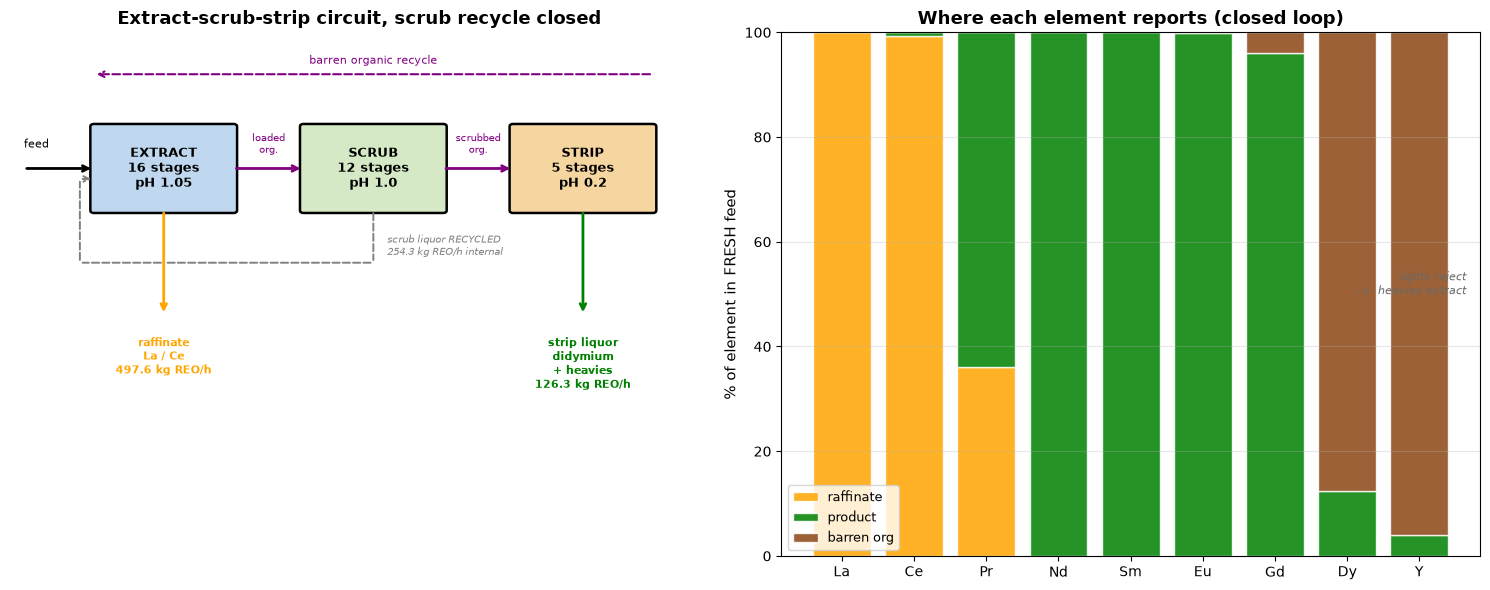

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Left: block flow diagram, all four outlets -----------------------
ax1 = axes[0]
ax1.set_xlim(0, 10); ax1.set_ylim(0, 10); ax1.axis("off")
ax1.set_title("Extract-scrub-strip circuit, scrub recycle closed",
              fontsize=13, fontweight="bold")

def block(ax, x, y, w, h, label, color):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.05",
        facecolor=color, edgecolor="black", linewidth=1.8))
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center",
            fontsize=9, fontweight="bold")

block(ax1, 1.2, 6.6, 2.0, 1.6, f"EXTRACT\n{N_EXTRACTION} stages\npH {EXTRACTION_PH}", "#bfd8ef")
block(ax1, 4.2, 6.6, 2.0, 1.6, f"SCRUB\n{N_SCRUBBING} stages\npH {SCRUBBING_PH}", "#d6e9c6")
block(ax1, 7.2, 6.6, 2.0, 1.6, f"STRIP\n{N_STRIPPING} stages\npH {STRIPPING_PH}", "#f5d5a0")

for x0, x1 in ((3.2, 4.2), (6.2, 7.2)):
    ax1.annotate("", xy=(x1, 7.4), xytext=(x0, 7.4),
                 arrowprops=dict(arrowstyle="->", lw=2, color="purple"))
ax1.text(3.7, 7.7, "loaded\norg.", fontsize=7, ha="center", color="purple")
ax1.text(6.7, 7.7, "scrubbed\norg.", fontsize=7, ha="center", color="purple")

ax1.annotate("", xy=(1.2, 7.4), xytext=(0.2, 7.4),
             arrowprops=dict(arrowstyle="->", lw=2, color="black"))
ax1.text(0.2, 7.8, "feed", fontsize=8)

outlets = [
    (2.2, "raffinate\nLa / Ce", "orange", "raffinate"),
    (8.2, "strip liquor\ndidymium\n+ heavies", "green", "product"),
]
for x, label, color, key in outlets:
    ax1.annotate("", xy=(x, 4.6), xytext=(x, 6.6),
                 arrowprops=dict(arrowstyle="->", lw=2, color=color))
    reo = float(ree_oxide_mass_flow({e: streams[key].get(e, 0.0)
                                     for e in all_elements})) * 3600
    ax1.text(x, 4.2, f"{label}\n{reo:.1f} kg REO/h",
             fontsize=8, ha="center", va="top", color=color, fontweight="bold")

ax1.annotate("", xy=(1.2, 9.2), xytext=(9.2, 9.2),
             arrowprops=dict(arrowstyle="->", lw=1.5, color="purple", ls="--"))
ax1.text(5.2, 9.4, "barren organic recycle", fontsize=8,
         ha="center", color="purple")
# Scrub liquor recycle: down out of the scrubber, back to the extraction feed.
for xy, xytext in (((5.2, 5.6), (5.2, 6.6)), ((2.2, 5.6), (5.2, 5.6)),
                   ((1.0, 7.2), (1.0, 5.6)), ((1.0, 5.6), (2.2, 5.6))):
    ax1.annotate("", xy=xy, xytext=xytext,
                 arrowprops=dict(arrowstyle="-", lw=1.4, color="grey", ls="--"))
ax1.annotate("", xy=(1.2, 7.2), xytext=(1.0, 7.2),
             arrowprops=dict(arrowstyle="->", lw=1.4, color="grey", ls="--"))
_rec_reo = float(ree_oxide_mass_flow(recycle)) * 3600
ax1.text(5.4, 5.75, f"scrub liquor RECYCLED\n{_rec_reo:.1f} kg REO/h internal",
         fontsize=7, color="grey", style="italic")

# ---- Right: where each element reports, stacked ------------------------
ax2 = axes[1]
order = list(all_elements)
bottom = np.zeros(len(order))
colors = {"raffinate": "orange", "product": "green",
          "barren org": "saddlebrown"}
for key, flows in streams.items():
    frac = np.array([float(flows.get(e, 0.0)) / float(feed_f[e]) * 100
                     for e in order])
    ax2.bar(order, frac, bottom=bottom, label=key,
            color=colors[key], alpha=0.85, edgecolor="white")
    bottom += frac
ax2.set_ylabel("% of element in FRESH feed", fontsize=11)
ax2.set_ylim(0, 100)
ax2.set_title("Where each element reports (closed loop)",
              fontsize=13, fontweight="bold")
ax2.legend(fontsize=9, loc="lower left")
ax2.grid(axis="y", alpha=0.3)
ax2.text(0.98, 0.5, "lights reject\n->  heavies extract", transform=ax2.transAxes,
         fontsize=8, ha="right", style="italic", color="dimgrey")

plt.tight_layout()
plt.show()

## 6. Cost structure

Two different pedigrees meet in this section, and they must not be read the same
way.

**The capital cost has a source.** `estimate_capex` does not build a factored
estimate from a per-stage equipment price. It takes its *level* from a project
cost somebody published, and moves that to this plant's capacity by the 0.6
power law and to this year by a CEPCI ratio. `capex_basis(scope)` names the
project, its citation key in `sources.yaml`, what the figure enclosed, and the
accuracy that follows. Three anchors are available and **they differ by more
than a factor of ten at the same capacity** — not because they disagree about
one plant, but because they draw the battery limits around different amounts of
plant:

| `scope` | Anchor | What the dollar figure enclosed |
|---|---|---|
| `sx_retrofit` | Energy Fuels White Mesa Phase 1 — **$16 M as-built**, 4,500 t/yr REO feed | Mixer-settler trains, their tanks, pumps, piping, instruments and installation. Buildings, power, utilities, effluent treatment and the licence were already there. |
| `separation_plant` | Avalon Nechalacho at Geismar, LA — **US$302 M**, 10,000 t/yr separated REO, 2012 prefeasibility | A standalone refinery: the cascade *plus* reagent handling, precipitation and calcination, effluent treatment, civils, electrical, utilities, engineering and contingency. No mine, no concentrator, no cracking plant. |
| `integrated` | Energy Fuels Phase 2 — **$410 M**, AACE Class 3 bankable study, ~7,554 t/yr separated products | The above *plus* monazite cracking and leaching. |

**The revenue line is on firmer ground than it was, and the operating line is
not.** The oxide prices are now `REFERENCE`, from the USGS *Mineral Commodity
Summaries*, for La, Ce, Pr, Nd, Eu and Gd — the six that carry essentially all
of the value here; Sm, Dy and Y are still `ESTIMATED` in the sense of section 0.
The payability below is an outright assumption about a commercial negotiation,
and every OPEX unit rate is a placeholder. So the capital and price lines can be
argued about with a document in hand; the payability and operating lines
cannot.

### Which scope this notebook uses, and why

`separation_plant`. The circuit simulated above starts from a leach liquor and
ends at two liquors, so on equipment alone `sx_retrofit` is the closer
description — and it is reported below as the brownfield bracket, which is the
right number if this cascade were dropped into a mill that already exists.

But it is the wrong number for a *project*. A facility that takes leach liquor
and ships concentrate still needs a building to stand in, power, steam, cooling
water, reagent storage, effluent treatment, a laboratory and a licence, and the
retrofit anchor got all of those free from an operating uranium mill. Charging
the greenfield figure is the conservative reading, and a section whose next step
is a payback period should take the conservative reading.

### Capacity basis, which the anchors do not agree on

`sx_retrofit` is quoted per tonne of REO **fed**; the other two per tonne of
**separated product**. For a full separation train those nearly coincide, and
Avalon's release says by how much: overall plant recovery 98 %, so its
10,000 t/yr of product came from 10,200 t/yr of feed and the basis does not
matter for that anchor. For this circuit they do not: 5,000 t/yr of REO goes in
and about 1,000 t/yr leaves in the didymium liquor, because the La and the Ce
are rejected rather than separated. The plant is sized by what flows through it,
so the feed tonnage is what is scaled here. Scaling the *product* tonnage
against these anchors instead would undersize the plant by a factor of five.

### And scaling one project is a Class 5 method

Capacity-factoring a single data point is AACE 18R-97 Class 5 — the widest
class there is — however well defined the anchor was. Avalon's own figure was
Class 4, and the study claims ±25 %; what comes out of the power law below
is about −50 %/+100 %, and that is the range to quote. `capex_basis` reports both so the
two cannot be confused.

### Payability, not "% of oxide price"

Neither of these streams is a finished oxide, so neither sells at the oxide
price. Two rules keep that honest:

1. Value the **contained oxide**, via `ree_oxide_mass_flow`, at the oxide prices
   the database quotes — not the metal mass, for the reason given in section 1.
2. Make the discount an explicit, named **payability** — the fraction of
   contained value a buyer actually pays for an unfinished concentrate — and
   vary it, because the answer is far more sensitive to it than to anything in
   the flowsheet. A bare "80 % of price" buried in a revenue line is the same
   assumption with the uncertainty hidden.

The two payabilities differ sharply, and not arbitrarily. A didymium-rich strip
liquor goes to a market that wants it. A La/Ce carbonate goes to a market in
structural surplus: La and Ce are co-produced with everything else in far
greater quantity than catalyst and polishing demand absorbs, which is why the
USGS quotes their oxides at $1.00 and $1.71/kg against $69/kg for Nd. Paying
10 % of a $1.71/kg oxide is close to paying nothing, and that is the honest
description of this stream — the plant rejects the cerium because there is
nothing else to do with it, not because rejecting it is worth money.

In [10]:
pricing = REEPricing()

# Payability: fraction of contained-oxide value a buyer pays for an
# unfinished concentrate. ASSUMPTIONS, stated as such -- not sourced.
PAYABILITY = {
    "product": 0.55,     # didymium-rich mixed strip liquor, wanted market
    "raffinate": 0.10,   # La/Ce carbonate, market in structural surplus
    "barren org": 0.0,   # regenerated solvent, not a product
}

def stream_value(flows, payability):
    """Annual contained-oxide value of a stream, USD/year."""
    rows, total = [], 0.0
    for elem in all_elements:
        mol_s = float(flows.get(elem, 0.0))
        if mol_s <= 0.0:
            continue
        kg_reo_yr = float(ree_oxide_mass_flow({elem: mol_s})) * 3600 * HOURS_PER_YEAR
        price = pricing.get_price(elem, "99%", "oxide")
        value = kg_reo_yr * price * payability
        total += value
        rows.append((elem, kg_reo_yr, price, value))
    return rows, total

print("Contained-oxide value by stream")
print("=" * 72)
revenue_by_stream = {}
for name in ("product", "raffinate"):
    pay = PAYABILITY[name]
    rows, subtotal = stream_value(streams[name], pay)
    revenue_by_stream[name] = subtotal
    print(f"\n{name.upper()}  (payability {pay:.0%} of contained oxide)")
    print(f"  {'el':>4} {'kg REO/yr':>11} {'$/kg oxide':>11} {'$k/yr':>10}")
    for elem, kg, price, value in sorted(rows, key=lambda r: -r[3]):
        if kg < 1:
            continue
        print(f"  {elem:>4} {kg:>11,.0f} {price:>11,.2f} {value / 1e3:>10,.1f}")
    print(f"  subtotal: ${subtotal / 1e6:.2f} M/year")

total_revenue = sum(revenue_by_stream.values())
print("\n" + "=" * 72)
print(f"TOTAL REVENUE: ${total_revenue / 1e6:.2f} M/year   "
      f"[prices USGS where REFERENCE; payability assumed]")
_rev_frac = revenue_by_stream["product"] / total_revenue * 100
_prod_reo = float(ree_oxide_mass_flow(
    {e: streams["product"].get(e, 0.0) for e in all_elements}))
_mass_frac = _prod_reo / reo_check * 100
print(f"\nThe strip liquor is {_rev_frac:.0f}% of revenue from "
      f"{_mass_frac:.0f}% of the contained REO mass.")
print(f"The raffinate is {100 - _mass_frac:.0f}% of the mass and "
      f"{100 - _rev_frac:.0f}% of the revenue. Four fifths of what")
print("this plant pumps, heats and settles is La and Ce, and at $1.00 and")
print("$1.71/kg they cannot pay for the pumping. That is the whole economics")
print("of a bastnasite separation plant in one line -- and it is why the")
print("oxidative roast ahead of the circuit matters so much: the cerium it")
print("removes never has to be pumped at all.")

Contained-oxide value by stream

PRODUCT  (payability 55% of contained oxide)
    el   kg REO/yr  $/kg oxide      $k/yr
    Nd     744,331       69.00   28,247.4
    Pr     173,967       69.00    6,602.1
    Sm      59,816       15.00      493.5
    Gd      12,776       30.00      210.8
    Eu       6,644       27.00       98.7
    Dy         246      450.00       60.9
    Ce      12,202        1.71       11.5
     Y         262       35.00        5.0
    La           1        1.00        0.0
  subtotal: $35.73 M/year

RAFFINATE  (payability 10% of contained oxide)
    el   kg REO/yr  $/kg oxide      $k/yr
    Pr      98,531       69.00      679.9
    Ce   1,636,077        1.71      279.8
    La   2,246,443        1.00      224.6
    Nd          53       69.00        0.4
  subtotal: $1.18 M/year

TOTAL REVENUE: $36.91 M/year   [prices USGS where REFERENCE; payability assumed]

The strip liquor is 97% of revenue from 20% of the contained REO mass.
The raffinate is 80% of the mass and 3%

In [11]:
annual_reo_tonnes = reo_check * 3600 * HOURS_PER_YEAR / 1000

# Battery limits, chosen deliberately: a standalone facility, not a cascade
# bolted into someone else's licensed mill. See the discussion above.
SCOPE = "separation_plant"
basis = capex_basis(SCOPE)

print(f"Capital cost basis: {basis['source']}  (sources.yaml)")
print("=" * 72)
print(f"  {basis['description']}")
print(f"  Disclosed        ${basis['capex_usd'] / 1e6:,.0f} M for "
      f"{basis['capacity_tpy']:,.0f} t/yr {basis['capacity_basis']}, "
      f"{basis['year']} basis")
print(f"  Anchor class     {basis['aace_class']}  "
      f"({basis['accuracy'][0]:+.0%} / {basis['accuracy'][1]:+.0%})")
print(f"  This estimate    {basis['derived_class']}  "
      f"({basis['derived_accuracy'][0]:+.0%} / "
      f"{basis['derived_accuracy'][1]:+.0%})")
print("  Includes:")
for line in basis["includes"]:
    print(f"    + {line}")
print("  Excludes:")
for line in basis["excludes"]:
    print(f"    - {line}")

# Costed on the SAME stage counts that were simulated -- N_EXTRACTION and
# friends are declared once, in section 3, and reused here. No
# n_stages_reference is passed: no anchor publishes a stage count, so there is
# no base case to move away from, and inventing one would put an unsourced
# number into the level rather than into the shape.
capex = estimate_capex(
    annual_ree_tonnes=annual_reo_tonnes,
    n_stages_extraction=N_EXTRACTION,
    n_stages_scrubbing=N_SCRUBBING,
    n_stages_stripping=N_STRIPPING,
    include_precipitation=False,   # selling concentrates, not finished oxides
    include_ce_removal=False,
    year=2024,
    scope=SCOPE,
)
brownfield = estimate_capex(
    annual_ree_tonnes=annual_reo_tonnes,
    n_stages_extraction=N_EXTRACTION,
    n_stages_scrubbing=N_SCRUBBING,
    n_stages_stripping=N_STRIPPING,
    include_precipitation=False,
    include_ce_removal=False,
    year=2024,
    scope="sx_retrofit",
)

print(f"\nPlant basis: {annual_reo_tonnes:.0f} t REO/year FED, "
      f"{N_EXTRACTION + N_SCRUBBING + N_STRIPPING} mixer-settler stages")
print(f"Capacity ratio to the anchor: "
      f"{annual_reo_tonnes / basis['capacity_tpy']:.3f}, "
      f"scaled at the 0.6 power")

print("\nCapital cost")
print("=" * 72)
for item, cost in capex.items():
    if cost > 0 and item != "total":
        print(f"  {item:<22s} ${cost / 1e6:>8,.1f} M")
print(f"  {'TOTAL':<22s} ${capex['total'] / 1e6:>8,.1f} M")
# The rows are a conventional split of an anchored total; only the total is
# anchored. If they ever stop summing to it, the split is what is broken.
assert abs(sum(v for k, v in capex.items() if k != "total")
           - capex["total"]) < 1.0

_lo, _hi = basis["derived_accuracy"]
print(f"\n  Range at the derived estimate class: "
      f"${capex['total'] * (1 + _lo) / 1e6:,.0f} M to "
      f"${capex['total'] * (1 + _hi) / 1e6:,.0f} M")
print(f"  Brownfield bracket ({basis['scope']} -> sx_retrofit): "
      f"${brownfield['total'] / 1e6:,.1f} M")
print(f"  -> the two brackets differ by "
      f"{capex['total'] / brownfield['total']:.0f}x at the same capacity, "
      f"same year,")
print("     same stages. That factor is battery limits, not disagreement.")

# include_precipitation must match the CAPEX flag: a circuit costed without a
# precipitation section should not be paying for precipitant. The assertion
# below is what keeps the two flags from drifting apart.
opex = estimate_opex(
    annual_ree_tonnes=annual_reo_tonnes,
    capex=capex["total"],
    extractant="PC88A",
    include_precipitation=False,
)
assert opex["precipitant"] == 0.0, "OPEX charges for a section we did not build"

print("\nOperating cost  [every unit rate ESTIMATED -- no source]")
print("=" * 72)
for item, cost in sorted(opex.items(), key=lambda kv: -kv[1]):
    if item != "total":
        print(f"  {item:<22s} ${cost / 1e6:>8,.2f} M/year")
print(f"  {'TOTAL':<22s} ${opex['total'] / 1e6:>8,.2f} M/year")
_top = max((k for k in opex if k != "total"), key=lambda k: opex[k])
print(f"\n  Largest line: {_top} (${opex[_top] / 1e6:.2f} M/yr, "
      f"{opex[_top] / opex['total'] * 100:.0f}% of OPEX)")
print(f"""
  Two of these lines deserve a second look. Extractant is the largest at
  ${opex['extractant'] / 1e6:.2f} M/yr -- an organophosphorus inventory turned over at an
  assumed degradation rate, and that rate is a placeholder. Maintenance is
  second at ${opex['maintenance'] / 1e6:.2f} M/yr, charged as a flat 3% of CAPEX, so it is
  the capital number wearing a different hat rather than an independent
  estimate of anything. Between them that is {(opex['extractant'] + opex['maintenance']) / opex['total'] * 100:.0f}% of the operating cost
  resting on two factors, against ${opex['labor'] / 1e6:.2f} M/yr of labor. A capital-heavy
  plant has a capital-heavy cost of ownership, and that is the first thing
  the brownfield bracket buys you out of.

  Note on the labor line: estimate_opex takes n_operators as TOTAL operating
  headcount, not headcount per shift -- the two readings differ by the number
  of crews. Six people covering 8000 h/year is a thin crew; staffing a
  continuous plant properly is about four rotating crews, so pass
  n_operators=24 for that. It would add ~${opex['labor'] * 3 / 1e6:.1f} M/yr.""")

# The one published operating rate any of the anchors gives, as a cross-check.
# Avalon: US$5,634 per tonne of separated REO at 10,000 t/yr, covering labour,
# supplies, reagents and maintenance -- no capital charge, no feed cost. Same
# exclusions as the total above, which is what makes the comparison legitimate.
from difflow_ree.economics.costs import CEPCI

AVALON_OPEX_PER_T = 5634.0          # sources.yaml:AVALON_GEISMAR, 2012 USD
_here = opex["total"] / annual_reo_tonnes
_avalon_2024 = AVALON_OPEX_PER_T * CEPCI[2024] / CEPCI[2012]
print(f"""
  Cross-check, and the only one available: Avalon's study puts operating cost
  at ${AVALON_OPEX_PER_T:,.0f}/t of REO at {basis['capacity_tpy']:,.0f} t/yr, ${_avalon_2024:,.0f}/t in
  2024 dollars on the same CEPCI ratio used for the capital. This circuit comes
  out at ${_here:,.0f}/t of REO fed -- {_here / _avalon_2024:.2f}x that rate, at
  {annual_reo_tonnes / basis['capacity_tpy']:.2f}x the capacity.

  Landing slightly BELOW the published rate at half the capacity is the wrong
  direction: labor and maintenance do not scale down with throughput, so a
  smaller plant should cost more per tonne, not less. The gap is not large
  enough to call the estimate wrong -- Avalon's feed and product slate are
  different, its figure carries a study contingency, and this circuit is one
  cascade rather than a full separation train -- but it is the direction to
  distrust, and it says the unit rates above are more likely optimistic than
  conservative. It is still the first number in this section that came from
  outside difflow, and the total is not off by an order of magnitude.""")


Capital cost basis: AVALON_GEISMAR  (sources.yaml)
  Avalon Rare Metals' proposed Nechalacho separation plant and refinery at Geismar, Louisiana: a standalone separation refinery on a greenfield site, fed with mixed concentrate from elsewhere. Prefeasibility study by SNC-Lavalin.
  Disclosed        $302 M for 10,000 t/yr separated REO, 2012 basis
  Anchor class     AACE Class 4 (prefeasibility), +/-25% claimed  (-25% / +25%)
  This estimate    AACE Class 5 (capacity-factored from one project)  (-50% / +100%)
  Includes:
    + "a complete separation plant facility; infrastructure, utilities and ancillary services; indirect costs; and contingency"
    + the full solvent-extraction house -- over 1,000 mixer-settlers, disclosed at 33% of the total, US$101 million
    + reagent receipt, storage and make-up
    + precipitation and calcination to saleable oxide
    + buildings, civils, electrical and utilities
    + engineering, offsites and contingency
  Excludes:
    - the mine and concentr

In [12]:
profit = calculate_profit(
    revenue=total_revenue,
    opex=opex["total"],
    capex=capex["total"],
)

print("Margin structure -- NOT a project evaluation")
print("=" * 72)
print(f"  Revenue        ${profit['revenue'] / 1e6:>10,.2f} M/year")
print(f"  OPEX           ${profit['opex'] / 1e6:>10,.2f} M/year")
print(f"  EBITDA         ${profit['ebitda'] / 1e6:>10,.2f} M/year")
print(f"  Depreciation   ${profit['depreciation'] / 1e6:>10,.2f} M/year")
print(f"  Net income     ${profit['net_income'] / 1e6:>10,.2f} M/year")
print(f"  CAPEX          ${capex['total'] / 1e6:>10,.2f} M")
payback = float(profit["payback_years"])
print(f"  Payback        {payback:>10.1f} years" if np.isfinite(payback)
      else "  Payback              never (cash flow <= 0)")
print(f"  ROI            {profit['roi'] * 100:>10.1f}%")

print("""
No verdict is printed here -- no "payback acceptable", no go/no-go. The
capital line is anchored to a disclosed project cost, but it is a Class 5
scaling of it, and everything it is compared against -- the prices, the
payability, every OPEX unit rate -- carries no identified source at all. A
sign test on those inputs carries no information about a project.

What IS supportable from the lines above:
""")
print(f"  * Depreciation alone is ${profit['depreciation'] / 1e6:.1f} M/yr "
      f"against ${total_revenue / 1e6:.1f} M/yr of revenue.")
print(f"    Straight-line over 10 years on ${capex['total'] / 1e6:.0f} M of "
      f"capital costs "
      f"{profit['depreciation'] / total_revenue:.1f}x")
print("    everything this plant sells. Closing that on operating cost alone")
print(f"    would mean cutting OPEX by "
      f"{-float(profit['net_income']) / opex['total'] * 100:.0f}%, which no improvement to this")
print(f"    flowsheet delivers -- and no error bar on the anchor closes it")
print(f"    either: at the low end of the Class 5 range, "
      f"${capex['total'] * (1 + _lo) / 1e6:.0f} M, depreciation is")
print(f"    ${capex['total'] * (1 + _lo) / 10 / 1e6:.1f} M/yr and net income is "
      f"still negative.")
print(f"  * EBITDA is {'positive' if profit['ebitda'] > 0 else 'negative'} "
      f"before capital charge, and section 7 shows how little")
print("    it takes to flip, because it depends on numbers nobody sourced.")
print(f"  * The largest operating line is {_top}, at "
      f"{opex[_top] / opex['total'] * 100:.0f}% of OPEX, on an assumed")
print(f"    degradation rate. The second is maintenance, "
      f"{opex['maintenance'] / opex['total'] * 100:.0f}% of OPEX -- and that")
print(f"    one is a flat 3% of CAPEX, so it is the capital number wearing a")
print(f"    different hat rather than an independent estimate of what running")
print(f"    this plant costs. Between them, "
      f"{(opex[_top] + opex['maintenance']) / opex['total'] * 100:.0f}% of the "
      f"operating cost rests on")
print(f"    two factors, against ${opex['labor'] / 1e6:.2f} M/yr of labor on a "
      f"headcount of six.")
print(f"  * On the brownfield bracket instead -- "
      f"${brownfield['total'] / 1e6:.1f} M, this cascade inside")
print("    an existing licensed mill -- depreciation is "
      f"${brownfield['total'] / 10 / 1e6:.2f} M/yr and the sign flips.")
_lace_liquor = (REO_LIQUOR["La"] + REO_LIQUOR["Ce"]) / sum(REO_LIQUOR.values()) * 100
print(f"    THAT is the structural result: at {annual_reo_tonnes:,.0f} t/yr of a "
      f"feed that is {_lace_liquor:.0f}%")
print("    La+Ce, the answer is decided by whether the project has to pay for")
print("    a site, not by anything in the flowsheet. Note that the roast has")
print("    already taken half the cerium out and the feed is STILL mostly")
print("    La+Ce -- that is how light-dominated a bastnasite liquor is.")

Margin structure -- NOT a project evaluation
  Revenue        $     36.91 M/year
  OPEX           $     28.91 M/year
  EBITDA         $      8.00 M/year
  Depreciation   $     25.41 M/year
  Net income     $    -17.41 M/year
  CAPEX          $    254.07 M
  Payback              31.8 years
  ROI                  -6.9%

No verdict is printed here -- no "payback acceptable", no go/no-go. The
capital line is anchored to a disclosed project cost, but it is a Class 5
scaling of it, and everything it is compared against -- the prices, the
payability, every OPEX unit rate -- carries no identified source at all. A
sign test on those inputs carries no information about a project.

What IS supportable from the lines above:

  * Depreciation alone is $25.4 M/yr against $36.9 M/yr of revenue.
    Straight-line over 10 years on $254 M of capital costs 0.7x
    everything this plant sells. Closing that on operating cost alone
    would mean cutting OPEX by 60%, which no improvement to this
    flowsh

## 7. What the answer actually depends on

The flowsheet has many knobs and the economics have two. Vary both and see which
one matters.

Payability is the assumption with no source at all — a guess about a commercial
negotiation. Nd price now *has* a source (USGS 2026), but a single annual
average is not a forecast: Nd oxide has traded between roughly $40 and $160/kg
within the last decade, so sweeping it is sensitising the sourced number rather
than papering over an unsourced one. Sweep both over ranges nobody can rule out
and compare the swing to the base EBITDA — the quantity a technoeconomic summary
would be tempted to render a verdict on.

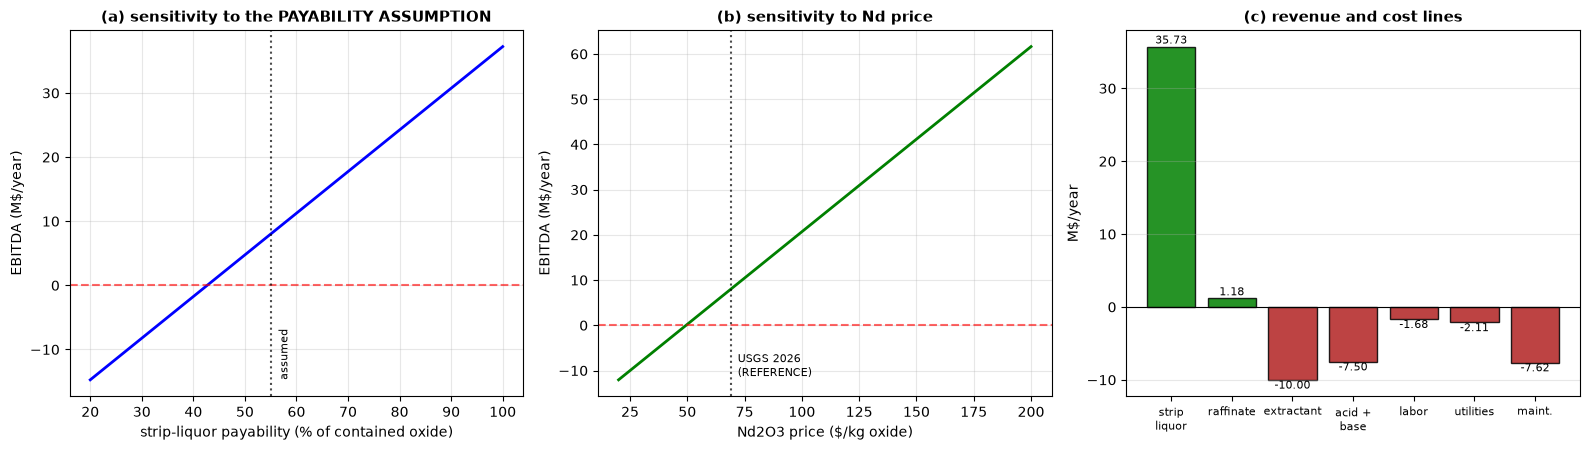

Base EBITDA at the assumed inputs:        $8.00 M/year
EBITDA span over payability 20-100%:      $51.97 M/year  (6x the base)
EBITDA span over Nd price $20-200/kg:      $73.69 M/year  (9x the base)

The two assumptions move EBITDA by comparable amounts, and each span is several
times the magnitude of the base EBITDA (6.5x and 9.2x). Panel (a) crosses zero at a
payability of 43%, and panel (b) at an Nd price of $49/kg -- both inside the range
of what is plausible, and the Nd crossing is inside the range the market has
actually traded through in the last ten years.

That is the result: the sign of EBITDA is set by one number nobody sourced and
one that is sourced but not forecastable, so the sign is not a finding. Neither
is any conclusion drawn from it -- which is why section 6 prints no verdict.
Note that EBITDA is the easy hurdle: it clears here, and net income does not,
because the capital charge is the line that does not move with either sweep.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# ---- (a) payability sweep ---------------------------------------------
ax = axes[0]
pays = np.linspace(0.2, 1.0, 161)
ebitda_pay = []
for pay in pays:
    _, prod_v = stream_value(streams["product"], pay)
    _, raff_v = stream_value(streams["raffinate"], PAYABILITY["raffinate"])
    pr = calculate_profit(revenue=prod_v + raff_v, opex=opex["total"],
                          capex=capex["total"])
    ebitda_pay.append(float(pr["ebitda"]) / 1e6)
ax.plot(pays * 100, ebitda_pay, "b-", lw=2)
ax.axhline(0, color="r", ls="--", alpha=0.6)
ax.axvline(PAYABILITY["product"] * 100, color="k", ls=":", alpha=0.7)
ax.text(PAYABILITY["product"] * 100 + 1.5, min(ebitda_pay),
        "assumed", fontsize=8, rotation=90, va="bottom")
ax.set_xlabel("strip-liquor payability (% of contained oxide)")
ax.set_ylabel("EBITDA (M$/year)")
ax.set_title("(a) sensitivity to the PAYABILITY ASSUMPTION",
             fontsize=11, fontweight="bold")
ax.grid(alpha=0.3)

# ---- (b) Nd price sweep -----------------------------------------------
ax = axes[1]
nd_kg_yr = float(ree_oxide_mass_flow(
    {"Nd": float(streams["product"].get("Nd", 0.0))})) * 3600 * HOURS_PER_YEAR
base_nd_price = pricing.get_price("Nd", "99%", "oxide")
nd_prices = np.linspace(20.0, 200.0, 181)
ebitda_nd = []
for nd_price in nd_prices:
    revenue_adj = total_revenue + nd_kg_yr * PAYABILITY["product"] * (
        nd_price - base_nd_price)
    pr = calculate_profit(revenue=revenue_adj, opex=opex["total"],
                          capex=capex["total"])
    ebitda_nd.append(float(pr["ebitda"]) / 1e6)
ax.plot(nd_prices, ebitda_nd, "g-", lw=2)
ax.axhline(0, color="r", ls="--", alpha=0.6)
ax.axvline(base_nd_price, color="k", ls=":", alpha=0.7)
ax.text(base_nd_price + 3, min(ebitda_nd), "USGS 2026\n(REFERENCE)",
        fontsize=8, va="bottom")
ax.set_xlabel("Nd2O3 price ($/kg oxide)")
ax.set_ylabel("EBITDA (M$/year)")
ax.set_title("(b) sensitivity to Nd price", fontsize=11, fontweight="bold")
ax.grid(alpha=0.3)

# ---- (c) cost/revenue breakdown ---------------------------------------
ax = axes[2]
labels = ["strip\nliquor", "raffinate", "extractant", "acid +\nbase",
          "labor", "utilities", "maint."]
values = [
    revenue_by_stream["product"] / 1e6,
    revenue_by_stream["raffinate"] / 1e6,
    -opex["extractant"] / 1e6,
    -(opex["acid"] + opex["base"]) / 1e6,
    -opex["labor"] / 1e6,
    -opex["utilities"] / 1e6,
    -opex["maintenance"] / 1e6,
]
ax.bar(labels, values,
       color=["green" if v > 0 else "firebrick" for v in values],
       alpha=0.85, edgecolor="black")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("M$/year")
ax.set_title("(c) revenue and cost lines", fontsize=11, fontweight="bold")
ax.tick_params(axis="x", labelsize=8)
ax.grid(axis="y", alpha=0.3)
for i, v in enumerate(values):
    ax.text(i, v + (0.05 if v >= 0 else -0.05), f"{v:.2f}",
            ha="center", va="bottom" if v >= 0 else "top", fontsize=8)

plt.tight_layout()
plt.show()

_span_pay = max(ebitda_pay) - min(ebitda_pay)
_span_nd = max(ebitda_nd) - min(ebitda_nd)
_base = float(profit["ebitda"]) / 1e6
print(f"Base EBITDA at the assumed inputs:        ${_base:.2f} M/year")
print(f"EBITDA span over payability 20-100%:      ${_span_pay:.2f} M/year"
      f"  ({_span_pay / abs(_base):.0f}x the base)")
print(f"EBITDA span over Nd price ${nd_prices[0]:.0f}-{nd_prices[-1]:.0f}/kg:"
      f"      ${_span_nd:.2f} M/year"
      f"  ({_span_nd / abs(_base):.0f}x the base)")
_pay_cross = np.interp(0.0, ebitda_pay, pays * 100)
_nd_cross = np.interp(0.0, ebitda_nd, nd_prices)
print(f"""
The two assumptions move EBITDA by comparable amounts, and each span is several
times the magnitude of the base EBITDA ({_span_pay / abs(_base):.1f}x and {_span_nd / abs(_base):.1f}x). Panel (a) crosses zero at a
payability of {_pay_cross:.0f}%, and panel (b) at an Nd price of ${_nd_cross:.0f}/kg -- both inside the range
of what is plausible, and the Nd crossing is inside the range the market has
actually traded through in the last ten years.

That is the result: the sign of EBITDA is set by one number nobody sourced and
one that is sourced but not forecastable, so the sign is not a finding. Neither
is any conclusion drawn from it -- which is why section 6 prints no verdict.
Note that EBITDA is the easy hurdle: it clears here, and net income does not,
because the capital charge is the line that does not move with either sweep.""")

## 8. Break-even, computed safely

The question "what Nd price would break even?" is a division by the Nd
production rate, and that division is a trap. A circuit that is barely working
does not produce zero — it produces some small positive number, which passes a
guard written as `if nd_mass_yr > 0` and then, as a divisor, yields a break-even
price that is nonsense. A second guard on the result being positive waves that
through too, because it is positive.

The dangerous case is not the one that produces `1e-16` and prints as `0`; that
one at least looks broken. It is the one below, which produces a few thousand
kilograms a year, formats like a real number, and returns a break-even price
with a plausible number of digits in it.

A smaller epsilon is not the answer, because there is no absolute mass that is
meaningful independent of plant size. The test has to be on the thing the
division actually requires: that Nd recovery is a *physically meaningful*
fraction of the feed. A circuit recovering under a percent of its target
element has no break-even price, and the right output is to say so rather than
to compute one.

At this operating point there is a real Nd stream, so the guard is not exercised
by the run below. The cell after it deliberately runs the circuit *outside* the
fitted pH window — at this notebook's own former design point, pH 3.2 / 3.0 /
1.5, which the `#270` refit put a full pH unit outside PC88A's window — and
shows both protections doing their jobs. It is not a hypothetical failure mode:
it is the operating point this notebook shipped with until the coefficients were
refitted, and the two guards are the reason that showed up as an assertion
rather than as a plausible-looking table.

In [14]:
nd_feed_kg_yr = float(ree_oxide_mass_flow(
    {"Nd": float(feed_f["Nd"])})) * 3600 * HOURS_PER_YEAR
nd_recovery = nd_kg_yr / nd_feed_kg_yr

# A break-even price is only defined if the stream we would sell exists.
# Threshold is on RECOVERY -- a dimensionless, physical quantity -- not on
# an absolute mass being "> 0", which 1e-16 satisfies.
MIN_RECOVERY_FOR_BREAKEVEN = 0.01

required_revenue = opex["total"] + float(profit["depreciation"])
revenue_gap = required_revenue - total_revenue

print("Break-even analysis")
print("=" * 66)
print(f"  Current revenue          ${total_revenue / 1e6:>8.2f} M/year")
print(f"  Required (OPEX + depr.)  ${required_revenue / 1e6:>8.2f} M/year")
print(f"  Gap                      ${revenue_gap / 1e6:>8.2f} M/year")
print(f"\n  Nd in feed               {nd_feed_kg_yr:>8,.0f} kg Nd2O3/year")
print(f"  Nd in strip liquor       {nd_kg_yr:>8,.0f} kg Nd2O3/year "
      f"({nd_recovery:.1%} recovery)")

if nd_recovery < MIN_RECOVERY_FOR_BREAKEVEN:
    print(f"""
  Nd recovery is {nd_recovery:.2e}, below the {MIN_RECOVERY_FOR_BREAKEVEN:.0%} threshold.
  NO BREAK-EVEN Nd PRICE EXISTS: there is no Nd product to reprice. The
  circuit is not extracting -- fix the operating point before asking an
  economic question about it.""")
elif revenue_gap <= 0:
    print(f"""
  Revenue already exceeds OPEX + depreciation at the assumed payability, so
  no Nd price increase is required. Note what that rests on: see section 7.""")
else:
    nd_revenue_per_dollar = nd_kg_yr * PAYABILITY["product"]
    breakeven_nd_price = base_nd_price + revenue_gap / nd_revenue_per_dollar
    print(f"""
  Nd price in database     ${base_nd_price:>8,.0f}/kg Nd2O3  [USGS 2026, REFERENCE]
  Realised, at {PAYABILITY['product']:.0%} pay      ${base_nd_price * PAYABILITY['product']:>8,.0f}/kg
  Break-even Nd price      ${breakeven_nd_price:>8,.0f}/kg Nd2O3
  -> a {(breakeven_nd_price / base_nd_price - 1) * 100:.0f}% increase over the database price.""")
    if breakeven_nd_price > 10 * base_nd_price:
        print("\n  That is more than 10x the reference price. Read it as "
              "'not at any\n  plausible price', not as a forecast.")

print("\n" + "=" * 66)
print("Scale-up: does this get better with size?")
print("=" * 66)
print("  CAPEX and OPEX are re-estimated at each capacity rather than scaled")
print("  by hand -- same anchor, same 0.6 exponent, same scope -- and labor")
print("  stays at the same headcount, because n_operators is not a function")
print("  of throughput.")
_sweep = []
for scale in (0.2, 0.5, 1, 2, 4, 8):
    scaled_tonnes = annual_reo_tonnes * scale
    scaled_capex = estimate_capex(
        annual_ree_tonnes=scaled_tonnes,
        n_stages_extraction=N_EXTRACTION,
        n_stages_scrubbing=N_SCRUBBING,
        n_stages_stripping=N_STRIPPING,
        include_precipitation=False, include_ce_removal=False,
        year=2024, scope=SCOPE,
    )["total"]
    scaled_opex = estimate_opex(
        annual_ree_tonnes=scaled_tonnes, capex=scaled_capex,
        extractant="PC88A", include_precipitation=False,
    )["total"]
    sp = calculate_profit(revenue=total_revenue * scale,
                          opex=scaled_opex, capex=scaled_capex)
    print(f"\n  {scale:>4g}x  ({scaled_tonnes:>6,.0f} t REO/yr fed)"
          f"  revenue ${total_revenue * scale / 1e6:>6.1f}M"
          f"  OPEX ${scaled_opex / 1e6:>6.1f}M"
          f"  CAPEX ${scaled_capex / 1e6:>5.0f}M")
    print(f"      EBITDA ${sp['ebitda'] / 1e6:>6.1f}M"
          f"   net income ${sp['net_income'] / 1e6:>6.1f}M"
          f"   ROI {sp['roi'] * 100:>5.1f}%")
    _sweep.append((scaled_tonnes, float(sp["net_income"])))

# Interpolate the crossing rather than reading it off the nearest row -- but
# NOT with np.interp: net income is NOT monotonic in scale (revenue is linear,
# CAPEX goes as the 0.6 power, and depreciation therefore falls per tonne only
# after the fixed operating lines have been diluted), so np.interp on it would
# be reading a lookup table that is not sorted and would be right only by
# accident. Find the last sign change and interpolate on that bracket.
_t = np.array([t for t, _ in _sweep])
_ni = np.array([n for _, n in _sweep])
_signs = np.sign(_ni)
_changes = np.nonzero(_signs[:-1] != _signs[1:])[0]
assert not np.all(_ni > 0) and _changes.size, (
    "net income does not change sign over the sweep -- report that, do not "
    "interpolate a crossing that is not there")
_i = int(_changes[-1])
_cross_t = float(_t[_i] - _ni[_i] * (_t[_i + 1] - _t[_i]) / (_ni[_i + 1] - _ni[_i]))
_anchor_t = capex_basis(SCOPE)["capacity_tpy"]
print(f"""
Net income is NOT monotonic in scale: it gets worse before it gets better,
because doubling the plant doubles the revenue but adds only 2**0.6 = 1.52x the
capital, and the capital charge is what dominates at the small end. The last
sign change is between {_t[_i]:,.0f} and {_t[_i + 1]:,.0f} t/yr, putting the crossing at about
{_cross_t:,.0f} t REO/year -- {_cross_t / _anchor_t:.1f}x the {_anchor_t:,.0f} t/yr the anchor project was
costed at, so it is an extrapolation past the one capacity where this
arithmetic is the disclosed figure restated in 2024 dollars.

Read that as the answer to a question rather than as a plan. The question is
what throughput a feed this dilute in payable metal needs in order to carry a
separation plant, and on these assumptions it is tens of thousands of tonnes a
year -- the scale at which bastnasite separation is actually done. The specific
crossing point is only as good as the payability behind it, so what carries is
the order of magnitude, not the number.""")


Break-even analysis
  Current revenue          $   36.91 M/year
  Required (OPEX + depr.)  $   54.32 M/year
  Gap                      $   17.41 M/year

  Nd in feed                744,384 kg Nd2O3/year
  Nd in strip liquor        744,331 kg Nd2O3/year (100.0% recovery)

  Nd price in database     $      69/kg Nd2O3  [USGS 2026, REFERENCE]
  Realised, at 55% pay      $      38/kg
  Break-even Nd price      $     112/kg Nd2O3
  -> a 62% increase over the database price.

Scale-up: does this get better with size?
  CAPEX and OPEX are re-estimated at each capacity rather than scaled
  by hand -- same anchor, same 0.6 exponent, same scope -- and labor
  stays at the same headcount, because n_operators is not a function
  of throughput.

   0.2x  ( 1,000 t REO/yr fed)  revenue $   7.4M  OPEX $   8.5M  CAPEX $   97M
      EBITDA $  -1.1M   net income $ -10.8M   ROI -11.2%

   0.5x  ( 2,500 t REO/yr fed)  revenue $  18.5M  OPEX $  16.5M  CAPEX $  168M
      EBITDA $   1.9M   net income $ -14.

In [15]:
# What the two protections actually protect against: run the same circuit
# outside the fitted pH window, where D collapses and the product vanishes.
# This notebook's OWN design point before #270 refitted PC88A: pH 3.2 extract,
# 3.0 scrub, 1.5 strip, 10/6/4 stages. It was inside the window that the
# pre-refit record declared ([0.1, 5.5]) and is a full pH unit outside the one
# the refitted record declares ((0.1, 2.5)).
OUTSIDE_WINDOW = dict(extraction_pH=3.2, scrubbing_pH=3.0, stripping_pH=1.5,
                      n_extraction_stages=10, n_scrubbing_stages=6,
                      n_stripping_stages=4, solvent_to_feed_ratio=1.0)

bad_params = ExtractScrubStripParams(
    extractant="PC88A", elements=all_elements,
    target_elements=("Pr", "Nd"),
    scrub_to_solvent_ratio=0.15, strip_to_solvent_ratio=0.3, **OUTSIDE_WINDOW,
)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    bad_results = ExtractScrubStripCircuit(bad_params)(bastnasite_feed, T=T_OP)
msgs = sorted({str(w.message) for w in caught
               if "validity range" in str(w.message)})

print("1. The correlation reports that it is being extrapolated.")
print("   Two of these three pH values sit above PC88A's fitted window:")
for m in msgs:
    print("     - " + m.split(". ")[0] + ".")
assert msgs, "expected the validity check to fire outside the window"

bad_prod = get_flows(bad_results["product"])
bad_nd_mol_s = float(bad_prod.get("Nd", 0.0))
bad_nd_kg_yr = float(ree_oxide_mass_flow({"Nd": bad_nd_mol_s})) * 3600 * HOURS_PER_YEAR
bad_recovery = bad_nd_kg_yr / nd_feed_kg_yr

print(f"""
2. What those conditions actually produce. At pH 3.2 everything extracts,
   including the La and the Ce -- but the strip is then at pH 1.5, where
   D(Nd) is still about 26, so nothing comes back out. The old design point
   does not merely lose selectivity; it loses the product:
     Nd in product   {bad_nd_mol_s:.3e} mol/s
                     {bad_nd_kg_yr:.3e} kg Nd2O3/year
     Nd recovery     {bad_recovery:.3e}   ({bad_recovery * 100:.2f}% of the Nd fed)

   Positive, so `if nd_mass_yr > 0` would pass. And it does not look broken:
   it formats as a few thousand kilogrammes a year, which in a table of
   results reads as a small plant rather than as a circuit that is not
   working. Used as a divisor it gives a break-even price that is wrong by
   a factor of fifty and shows no sign of it:""")
_bad_breakeven = base_nd_price + revenue_gap / (bad_nd_kg_yr * PAYABILITY["product"])
print(f"     break-even Nd price on that stream  ->  ${_bad_breakeven:,.0f}/kg")
print(f"     (against ${breakeven_nd_price:,.0f}/kg at the real operating point)")

print("\n3. The recovery guard, tested on the same quantity:")
if bad_recovery < MIN_RECOVERY_FOR_BREAKEVEN:
    print(f"     recovery {bad_recovery:.2e} < threshold "
          f"{MIN_RECOVERY_FOR_BREAKEVEN:.0%}  ->  REFUSED, no division performed.")
else:
    print("     guard did not fire -- the assertion below catches that")
assert bad_recovery < MIN_RECOVERY_FOR_BREAKEVEN

print("""
The threshold is on recovery -- dimensionless, physical, and independent of
plant size -- so it cannot be satisfied by a number that is merely positive.
The two protections are complementary: the first says the physics is being
extrapolated, the second refuses to build an economic conclusion on top of it.

It is worth being blunt about what this cell is. The numbers above are what
this notebook printed as its base case until PC88A was refitted -- against a
declared validity window that the old record set at [0.1, 5.5] and the new one
sets at (0.1, 2.5). Nothing in the notebook was wrong about the arithmetic. The
window moved under it, and the only reason that surfaced as a failed assertion
instead of as a slightly different-looking table is that the assertion in
section 3 was armed.""")

1. The correlation reports that it is being extrapolated.
   Two of these three pH values sit above PC88A's fitted window:
     - pH maximum 3 is outside the validity range of the 'PC88A' pH correlation ([0.1, 2.5]) (#262).
     - pH maximum 3.2 is outside the validity range of the 'PC88A' pH correlation ([0.1, 2.5]) (#262).

2. What those conditions actually produce. At pH 3.2 everything extracts,
   including the La and the Ce -- but the strip is then at pH 1.5, where
   D(Nd) is still about 26, so nothing comes back out. The old design point
   does not merely lose selectivity; it loses the product:
     Nd in product   1.162e-03 mol/s
                     5.629e+03 kg Nd2O3/year
     Nd recovery     7.562e-03   (0.76% of the Nd fed)

   Positive, so `if nd_mass_yr > 0` would pass. And it does not look broken:
   it formats as a few thousand kilogrammes a year, which in a table of
   results reads as a small plant rather than as a circuit that is not
   working. Used as a divisor it

## Summary

### What was built

An oxidative roast, then a single PC88A extract-scrub-strip circuit on the
resulting Mountain Pass bastnasite leach liquor, specified on a rare-earth-oxide
basis at 5,000 t REO/year, with the scrub recycle closed to a fixed point and
the element balance closed on the fresh feed across all three external outlets
to better than 1e-6 percentage points.

The roast is not decoration. Bastnasite is about half cerium, and calcining at
600–800 °C converts roughly half of that Ce(III) to Ce(IV), which does not
dissolve in the HCl leach and leaves with the residue. It is the largest single
separation in the flowsheet and it happens in a furnace. An earlier version of
this notebook fed the as-mined distribution straight to solvent extraction and
then conceded in its own summary that a real plant would not; feeding the liquor
instead is what makes the didymium result below reachable at all.

### What the simulation says

| | |
|---|---|
| Operating point | pH 1.05 extract / 1.00 scrub / 0.20 strip, all inside PC88A's fitted `(0.1, 2.5)` |
| Stages | 16 extract / 12 scrub / 5 strip — the same counts that are costed |
| Scrub recycle | closed; converges in ~32 passes, loop gain ≈ 0.49 |
| Nd recovery | ~100 % of fresh feed (72 % on a single pass) |
| Pr recovery | ~64 % — the rest is the price of rejecting Ce |
| Product | ~91 mol % Pr+Nd, against a feed-fixed ceiling of 92 % |
| La / Ce rejection | La complete; Ce ~99 % rejected to the raffinate |
| Dy / Y | ~88 % and ~96 % leave in the *barren organic* — they never strip |

### What is a result and what is an artifact

**Results** — the *structure* holds regardless of the data quality:

1. **The feed, not the separation, sets the economics.** Even after the roast
   has removed half the cerium, 78 % of what reaches solvent extraction is La
   and Ce, and USGS quotes those oxides at $1.00 and $1.71/kg against $69/kg for
   Nd. The strip liquor is ~20 % of the REO mass and ~97 % of the revenue. A
   circuit that separates perfectly still has to sell what the ore contains.
2. **One section makes one cut, and the feed fixes the ceiling.** Because every
   element shares `b = 3`, selectivity lives entirely in the intercepts and
   `log10 β_ij = a_i − a_j` — β does not move with pH, temperature or extractant
   concentration. Choosing the extraction pH is choosing *where on that ladder
   to cut*, and everything on the product side of the cut reports to the
   product. Here that puts the Pr+Nd ceiling at 92 mol %, and the circuit
   reaches 91.2. There is no operating point, stage count or flow ratio that
   does better; a second cut needs a second circuit.
3. **Pr is structurally awkward, and the number says why.** β(Pr/Ce) = 2.14 and
   β(Nd/Pr) = 2.14 — Pr sits at the midpoint of the Ce–Nd gap, so every
   increment of Ce rejection costs about the same increment of Pr. A third of
   the Pr leaves in the raffinate, and no scrub ratio fixes that; it is
   arithmetic on the intercepts. It is survivable only because the product is
   didymium, so Pr that *does* arrive counts as product rather than as impurity.
4. **Capital charge dominates at this scale.** Against a capital cost anchored
   to a disclosed separation-refinery figure, EBITDA is positive and net income
   is not: depreciation alone is about two thirds of total revenue. The scale
   sweep in section 8 does not turn positive until tens of thousands of tonnes a
   year, and it gets *worse* before it gets better, because doubling the plant
   doubles revenue and adds only 1.5× the capital. Small REE separation plants
   are not cheap plants that need better prices; they are capital projects whose
   product stream is too small to carry the capital. The one thing that moves it
   is not paying for the site — hence the brownfield bracket, and hence the fact
   that the plant that actually got built this way was a retrofit into an
   operating mill.
5. **The answer's sign hangs on assumptions no engineer controls.** Payability
   and Nd price each move EBITDA by several times the base EBITDA, and each
   crosses zero inside the range of the plausible. No amount of flowsheet
   optimisation touches that, which is why no verdict is printed.
6. **The scrub liquor is not a waste stream.** On a single pass it carries about
   half the Pr and a quarter of the Nd. Reading only the raffinate and the
   product loses that, and loses the mass balance with it.
7. **Dy and Y do not strip.** A strip pH chosen for Nd leaves them in the
   organic, and this flowsheet has no second strip to take them out. On this
   heavy-poor feed the amounts are trivial; on a heavy-rich feed the organic
   inventory would build up pass after pass, and the balance in section 4 is
   what makes that visible rather than invisible.

**Artifacts** — properties of this dataset, not of the process:

1. **Every absolute figure.** Recoveries, purities, revenues, payback. The
   distribution coefficients are now `MEASURED` — refit in `#270` against
   Tanaka et al. (2021) with `b` pinned at the proton stoichiometry — which is a
   real improvement over the `HAND_TUNED` set this notebook used to run on, but
   they are still one extractant at one concentration at one temperature. The
   payability and every OPEX unit rate carry no identified source at all, and
   three of the nine prices (Sm, Dy, Y) are `ESTIMATED`. See section 0.
2. **The capital line, with a caveat in its favour.** The *total* is a
   `DISCLOSED` project cost scaled to this capacity, so it can be argued about
   against a filing — but only at AACE Class 5 accuracy, and only for the
   battery limits `capex_basis` prints. Its line-item breakdown is `ESTIMATED`.
   The one available operating cross-check (Avalon) says this OPEX is, if
   anything, slightly optimistic.
3. **The exact split of the Pr.** 64 % recovered rather than 60 % or 70 % is a
   property of these intercepts and this scrub ratio. That Pr splits *at all*,
   and that it is the element that does, is not (result 3).

### What would make this a real study

Distribution coefficients measured at this circuit's actual loading and ionic
strength rather than at the correlation's reference state; a payability from an
actual term sheet; an equipment list costed from quotations, which is what takes
the capital estimate from Class 5 to something a lender would read; a second
circuit to make the Ce/La split the raffinate still needs; and a Dy/Y strip so
the organic loop closes.
